In [364]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Best test loss epoch
def find_best_epoch(metrics_csv, rmse_column):
    df = pd.read_csv(metrics_csv)
    best_epoch = df.loc[df[rmse_column].idxmin()]
    return int(best_epoch['Epoch']), best_epoch[rmse_column]

# Last epoch
def find_last_epoch(metrics_csv, rmse_column):
    df = pd.read_csv(metrics_csv)
    last_epoch = df.iloc[-1]
    return int(last_epoch['Epoch']), last_epoch[rmse_column]

---
### BERT-BLSTM w/ Finetuned BERT_MLM_ESM_INIT

Best test RMSE at epoch x:
SGD, LR=1e-5: epoch 517, rmse 1.9040
ADAM, LR=1e-5: epoch 945, rmse 1.1085
ADAM, LR=1e-4: epoch 620, rmse 1.0038


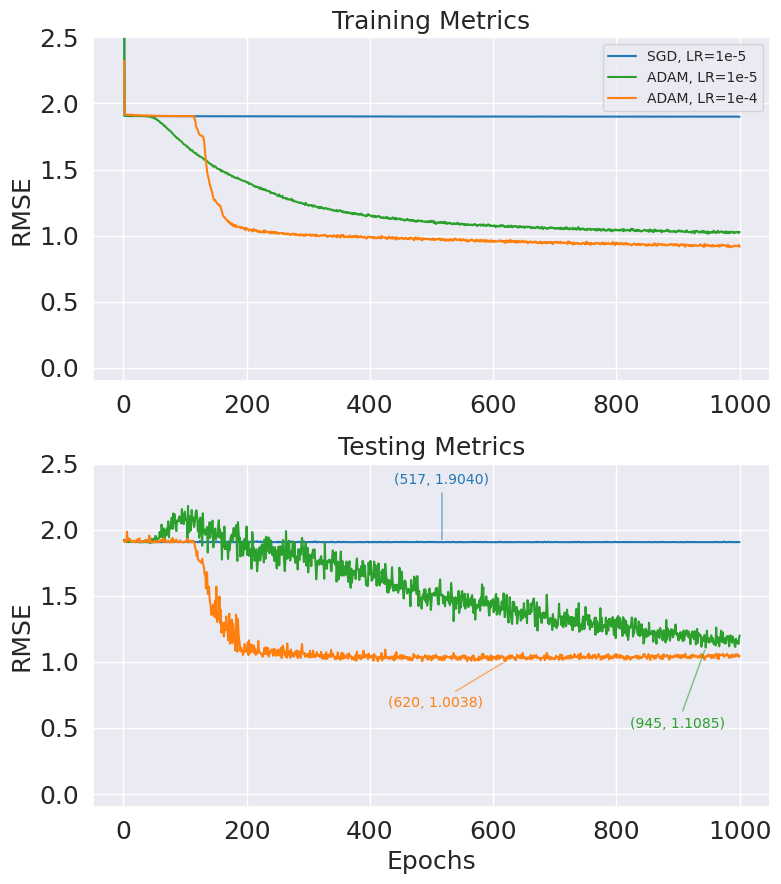

In [365]:
def plot_comparative_lr_log_file(metrics_csv_1, metrics_csv_2, metrics_csv_3, metrics_img):
    df1 = pd.read_csv(metrics_csv_1)
    df2 = pd.read_csv(metrics_csv_2)
    df3 = pd.read_csv(metrics_csv_3)

    sns.set_theme(style="darkgrid")
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 9))  # 2 rows, 1 column
    fontsize = 18

    # Plot 1: Training Metrics (binding, expression)
    ax1.plot(df1['Epoch'], df1['Train BLSTM RMSE'], label='SGD, LR=1e-5', color='tab:blue', linestyle='-', linewidth=1.5)
    ax1.plot(df2['Epoch'], df2['Train BLSTM RMSE'], label='ADAM, LR=1e-5', color='tab:green', linestyle='-', linewidth=1.5)
    ax1.plot(df3['Epoch'], df3['Train BLSTM RMSE'], label='ADAM, LR=1e-4', color='tab:orange', linestyle='-', linewidth=1.5)

    ax1.tick_params(axis='x', labelsize=fontsize)    
    ax1.set_xlim(-50, 1050)
    ax1.set_ylabel('RMSE', fontsize=fontsize)
    ax1.tick_params(axis='y', labelsize=fontsize)
    ax1.set_ylim(-0.1, 2.5)
    ax1.legend(loc='upper right', fontsize=fontsize-8)
    ax1.set_title('Training Metrics', fontsize=fontsize)

    # Plot Best Test Loss
    best_df1_rmse = find_best_epoch(metrics_csv_1, 'Test BLSTM RMSE')
    best_df2_rmse = find_best_epoch(metrics_csv_2, 'Test BLSTM RMSE')
    best_df3_rmse = find_best_epoch(metrics_csv_3, 'Test BLSTM RMSE')
    
    print("Best test RMSE at epoch x:")
    print(f"SGD, LR=1e-5: epoch {best_df1_rmse[0]}, rmse {best_df1_rmse[1]:.4f}")
    print(f"ADAM, LR=1e-5: epoch {best_df2_rmse[0]}, rmse {best_df2_rmse[1]:.4f}")
    print(f"ADAM, LR=1e-4: epoch {best_df3_rmse[0]}, rmse {best_df3_rmse[1]:.4f}")

    ax2.annotate(
        f'({best_df1_rmse[0]}, {best_df1_rmse[1]:.4f})', best_df1_rmse, 
        textcoords="offset points", xytext=(0,50), ha='center', va='top', color='tab:blue', fontsize=fontsize-8,
        arrowprops=dict(arrowstyle="-", color='tab:blue', lw=1, alpha=0.6)
    )
    ax2.annotate(
        f'({best_df2_rmse[0]}, {best_df2_rmse[1]:.4f})', best_df2_rmse, 
        textcoords="offset points", xytext=(-20,-50), ha='center', va='top', color='tab:green', fontsize=fontsize-8,
        arrowprops=dict(arrowstyle="-", color='tab:green', lw=1, alpha=0.6)
    )
    ax2.annotate(
        f'({best_df3_rmse[0]}, {best_df3_rmse[1]:.4f})', best_df3_rmse, 
        textcoords="offset points", xytext=(-50,-25), ha='center', va='top', color='tab:orange', fontsize=fontsize-8,
        arrowprops=dict(arrowstyle="-", color='tab:orange', lw=1, alpha=0.6)
    )

    # Plot 2: Testing Metrics (binding, expression)
    ax2.plot(df1['Epoch'], df1['Test BLSTM RMSE'], label='SGD, LR=1e-5', color='tab:blue', linestyle='-', linewidth=1.5)
    ax2.plot(df2['Epoch'], df2['Test BLSTM RMSE'], label='ADAM, LR=1e-5', color='tab:green', linestyle='-', linewidth=1.5)
    ax2.plot(df3['Epoch'], df3['Test BLSTM RMSE'], label='ADAM, LR=1e-4', color='tab:orange', linestyle='-', linewidth=1.5)

    ax2.set_xlabel('Epochs', fontsize=fontsize)
    ax2.tick_params(axis='x', labelsize=fontsize)
    ax2.set_xlim(-50, 1050)
    ax2.set_ylabel('RMSE', fontsize=fontsize)
    ax2.tick_params(axis='y', labelsize=fontsize)
    ax2.set_ylim(-0.1, 2.5)
    ax2.set_title('Testing Metrics', fontsize=fontsize)

    plt.tight_layout()
    plt.savefig(metrics_img, format='pdf')
    plt.savefig(metrics_img.replace('.pdf', '.png'), format='png')

b_sgd_lr_1e_neg_5 = "../../results/run_results/bert_blstm/sgd.lr1e-5.bert_blstm-DMS_OLD-binding-2024-11-15_18-14/bert_blstm-DMS_OLD-train_82178_test_20545_metrics.csv"
b_adam_lr_1e_neg_5 = "../../results/run_results/bert_blstm/adam.lr1e-5.bert_blstm-DMS_OLD-binding-2024-11-06_18-01/bert_blstm-DMS_OLD-train_82178_test_20545_metrics.csv"
b_adam_lr_1e_neg_4 = "../../results/run_results/bert_blstm/adam.lr1e-4.bert_blstm-DMS_OLD-binding-2024-11-23_21-43/bert_blstm-DMS_OLD-train_82178_test_20545_metrics.csv"
comparison_file = "../../results/plots/model_comparisons/finetuning/bert_blstm.binding"
plot_comparative_lr_log_file(b_sgd_lr_1e_neg_5,b_adam_lr_1e_neg_5, b_adam_lr_1e_neg_4, f"{comparison_file}.model_comp.pdf")

Best test RMSE at epoch x:
SGD, LR=1e-5: epoch 582, rmse 0.9959
ADAM, LR=1e-5: epoch 984, rmse 0.5851
ADAM, LR=1e-4: epoch 937, rmse 0.5572


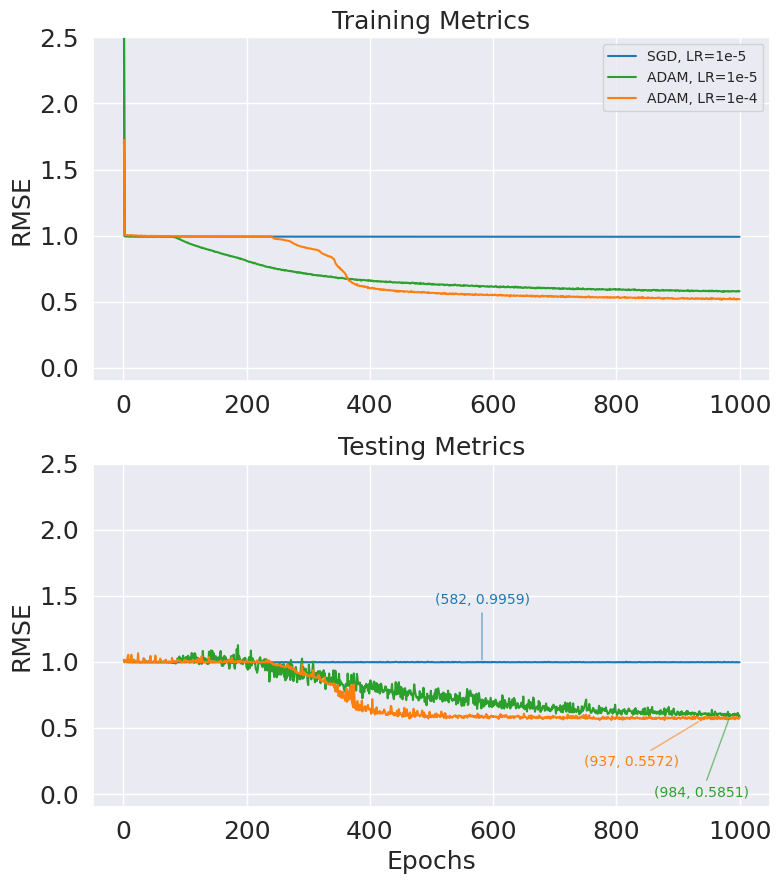

In [366]:
e_sgd_lr_1e_neg_5 = "../../results/run_results/bert_blstm/sgd.lr1e-5.bert_blstm-DMS_OLD-expression-2024-11-15_18-15/bert_blstm-DMS_OLD-train_82178_test_20545_metrics.csv"
e_adam_lr_1e_neg_5 = "../../results/run_results/bert_blstm/adam.lr1e-5.bert_blstm-DMS_OLD-expression-2024-11-06_18-01/bert_blstm-DMS_OLD-train_82178_test_20545_metrics.csv"
e_adam_lr_1e_neg_4 = "../../results/run_results/bert_blstm/adam.lr1e-4.bert_blstm-DMS_OLD-expression-2024-11-23_21-41/bert_blstm-DMS_OLD-train_82178_test_20545_metrics.csv"
comparison_file = "../../results/plots/model_comparisons/finetuning/bert_blstm.expression"
plot_comparative_lr_log_file(e_sgd_lr_1e_neg_5,e_adam_lr_1e_neg_5, e_adam_lr_1e_neg_4, f"{comparison_file}.model_comp.pdf")

--- 
### ESM-FCN

Best test RMSE at epoch x:
SGD, LR=1e-5: epoch 54, rmse 0.5699
ADAM, LR=1e-5: epoch 400, rmse 0.5235
ADAM, LR=1e-4: epoch 90, rmse 0.5313


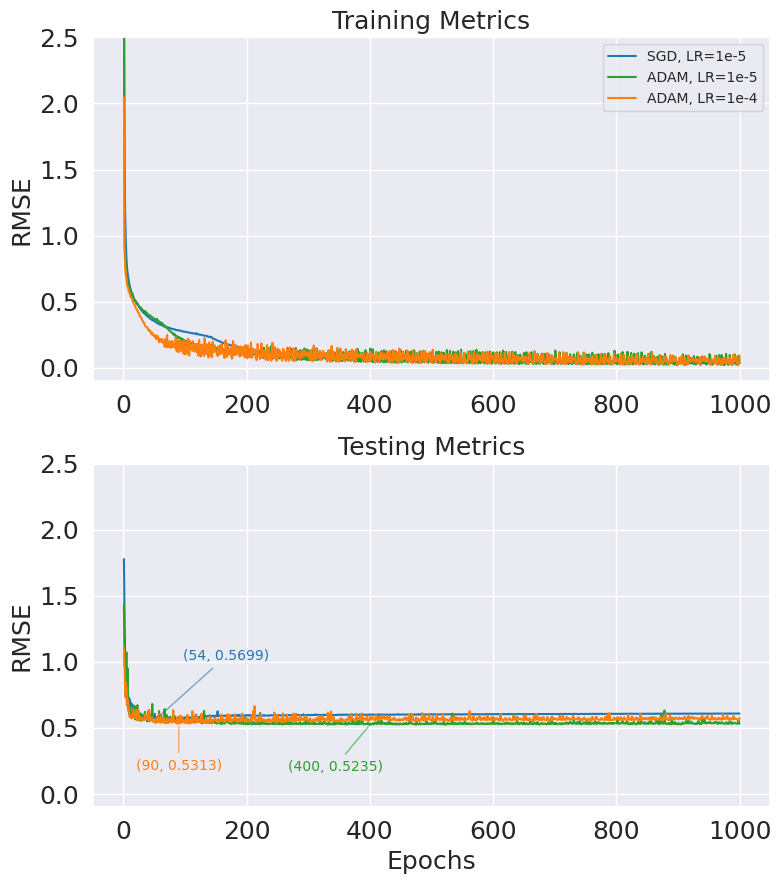

In [367]:
def plot_comparative_lr_log_file(metrics_csv_1, metrics_csv_2, metrics_csv_3, metrics_img):
    df1 = pd.read_csv(metrics_csv_1)
    df2 = pd.read_csv(metrics_csv_2)
    df3 = pd.read_csv(metrics_csv_3)

    sns.set_theme(style="darkgrid")
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 9))  # 2 rows, 1 column
    fontsize = 18

    # Plot 1: Training Metrics (binding, expression)
    ax1.plot(df1['Epoch'], df1['Train RMSE'], label='SGD, LR=1e-5', color='tab:blue', linestyle='-', linewidth=1.5)
    ax1.plot(df2['Epoch'], df2['Train RMSE'], label='ADAM, LR=1e-5', color='tab:green', linestyle='-', linewidth=1.5)
    ax1.plot(df3['Epoch'], df3['Train RMSE'], label='ADAM, LR=1e-4', color='tab:orange', linestyle='-', linewidth=1.5)

    ax1.tick_params(axis='x', labelsize=fontsize)    
    ax1.set_xlim(-50, 1050)
    ax1.set_ylabel('RMSE', fontsize=fontsize)
    ax1.tick_params(axis='y', labelsize=fontsize)
    ax1.set_ylim(-0.1, 2.5)
    ax1.legend(loc='upper right', fontsize=fontsize-8)
    ax1.set_title('Training Metrics', fontsize=fontsize)

    # Plot Best Test Loss
    best_df1_rmse = find_best_epoch(metrics_csv_1, 'Test RMSE')
    best_df2_rmse = find_best_epoch(metrics_csv_2, 'Test RMSE')
    best_df3_rmse = find_best_epoch(metrics_csv_3, 'Test RMSE')
    
    print("Best test RMSE at epoch x:")
    print(f"SGD, LR=1e-5: epoch {best_df1_rmse[0]}, rmse {best_df1_rmse[1]:.4f}")
    print(f"ADAM, LR=1e-5: epoch {best_df2_rmse[0]}, rmse {best_df2_rmse[1]:.4f}")
    print(f"ADAM, LR=1e-4: epoch {best_df3_rmse[0]}, rmse {best_df3_rmse[1]:.4f}")

    ax2.annotate(
        f'({best_df1_rmse[0]}, {best_df1_rmse[1]:.4f})', best_df1_rmse, 
        textcoords="offset points", xytext=(50,50), ha='center', va='top', color='tab:blue', fontsize=fontsize-8,
        arrowprops=dict(arrowstyle="-", color='tab:blue', lw=1, alpha=0.6)
    )
    ax2.annotate(
        f'({best_df2_rmse[0]}, {best_df2_rmse[1]:.4f})', best_df2_rmse, 
        textcoords="offset points", xytext=(-25,-25), ha='center', va='top', color='tab:green', fontsize=fontsize-8,
        arrowprops=dict(arrowstyle="-", color='tab:green', lw=1, alpha=0.6)
    )
    ax2.annotate(
        f'({best_df3_rmse[0]}, {best_df3_rmse[1]:.4f})', best_df3_rmse, 
        textcoords="offset points", xytext=(0,-25), ha='center', va='top', color='tab:orange', fontsize=fontsize-8,
        arrowprops=dict(arrowstyle="-", color='tab:orange', lw=1, alpha=0.6)
    )

    # Plot 2: Testing Metrics (binding, expression)
    ax2.plot(df1['Epoch'], df1['Test RMSE'], label='SGD, LR=1e-5', color='tab:blue', linestyle='-', linewidth=1.5)
    ax2.plot(df2['Epoch'], df2['Test RMSE'], label='ADAM, LR=1e-5', color='tab:green', linestyle='-', linewidth=1.5)
    ax2.plot(df3['Epoch'], df3['Test RMSE'], label='ADAM, LR=1e-4', color='tab:orange', linestyle='-', linewidth=1.5)

    ax2.set_xlabel('Epochs', fontsize=fontsize)
    ax2.tick_params(axis='x', labelsize=fontsize)
    ax2.set_xlim(-50, 1050)
    ax2.set_ylabel('RMSE', fontsize=fontsize)
    ax2.tick_params(axis='y', labelsize=fontsize)
    ax2.set_ylim(-0.1, 2.5)
    ax2.set_title('Testing Metrics', fontsize=fontsize)

    plt.tight_layout()
    plt.savefig(metrics_img, format='pdf')
    plt.savefig(metrics_img.replace('.pdf', '.png'), format='png')

b_sgd_lr_1e_neg_5 = "../../results/run_results/esm_fcn/sgd.lr1e-5.esm_fcn-DMS_OLD-binding-2024-11-22_07-39/esm_fcn-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
b_adam_lr_1e_neg_5 = "../../results/run_results/esm_fcn/adam.lr1e-5.esm_fcn-DMS_OLD-binding-2024-11-23_20-45/esm_fcn-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
b_adam_lr_1e_neg_4 = "../../results/run_results/esm_fcn/adam.lr1e-4.esm_fcn-DMS_OLD-binding-2024-11-24_05-48/esm_fcn-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
comparison_file = "../../results/plots/model_comparisons/finetuning/esm_fcn.binding"
plot_comparative_lr_log_file(b_sgd_lr_1e_neg_5,b_adam_lr_1e_neg_5, b_adam_lr_1e_neg_4, f"{comparison_file}.model_comp.pdf")

Best test RMSE at epoch x:
SGD, LR=1e-5: epoch 69, rmse 0.3438
ADAM, LR=1e-5: epoch 998, rmse 0.3171
ADAM, LR=1e-4: epoch 159, rmse 0.3163


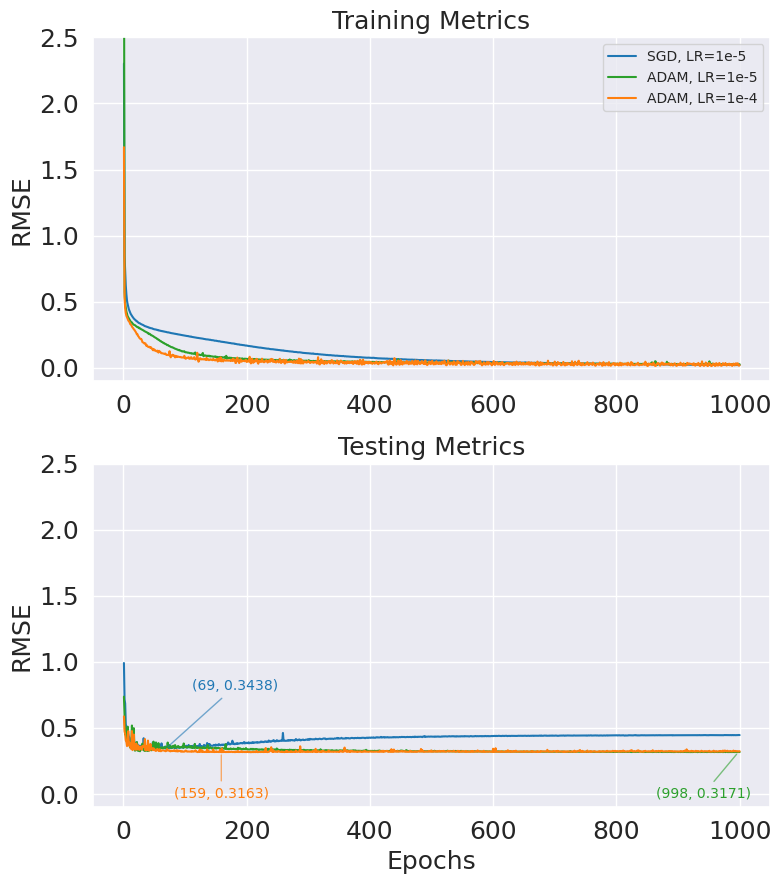

In [368]:
e_sgd_lr_1e_neg_5 = "../../results/run_results/esm_fcn/sgd.lr1e-5.esm_fcn-DMS_OLD-expression-2024-11-22_07-40/esm_fcn-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
e_adam_lr_1e_neg_5 = "../../results/run_results/esm_fcn/adam.lr1e-5.esm_fcn-DMS_OLD-expression-2024-11-23_21-22/esm_fcn-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
e_adam_lr_1e_neg_4 = "../../results/run_results/esm_fcn/adam.lr1e-4.esm_fcn-DMS_OLD-expression-2024-11-24_05-47/esm_fcn-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
comparison_file = "../../results/plots/model_comparisons/finetuning/esm_fcn.expression"
plot_comparative_lr_log_file(e_sgd_lr_1e_neg_5,e_adam_lr_1e_neg_5, e_adam_lr_1e_neg_4, f"{comparison_file}.model_comp.pdf")

---
### ESM-GCN

Best test RMSE at epoch x:
SGD, LR=1e-5: epoch 66, rmse 0.5733
ADAM, LR=1e-5: epoch 351, rmse 0.5272
ADAM, LR=1e-4: epoch 58, rmse 0.5426


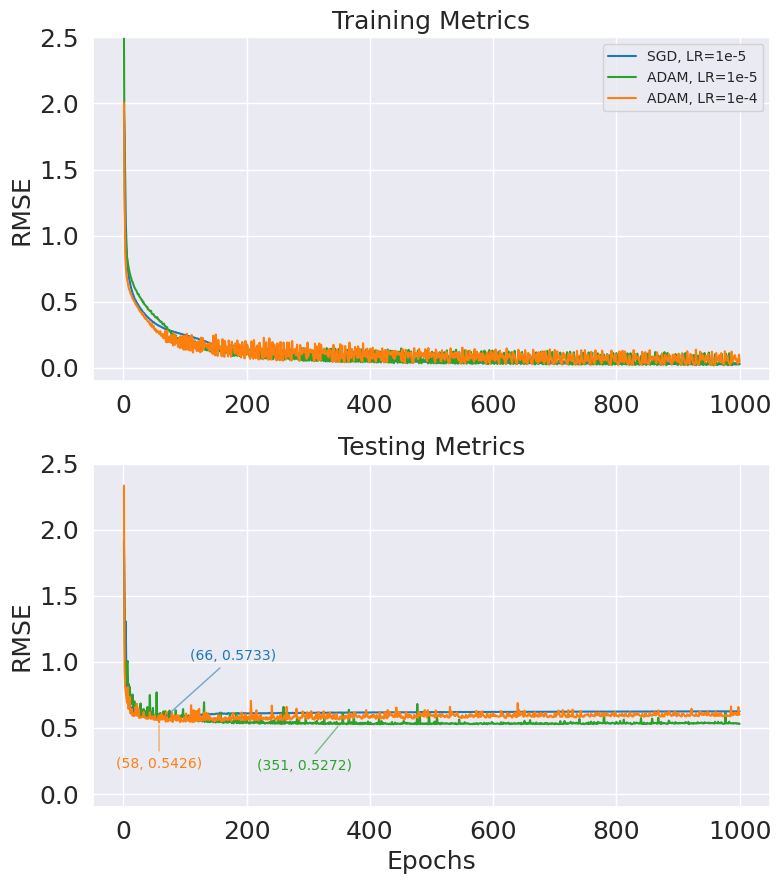

In [369]:
b_sgd_lr_1e_neg_5 = "../../results/run_results/esm_gcn/sgd.lr1e-5.esm-gcn-DMS_OLD-binding-2024-11-15_19-12/esm-gcn-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
b_adam_lr_1e_neg_5 = "../../results/run_results/esm_gcn/adam.lr1e-5.esm_gcn-DMS_OLD-binding-2024-11-23_21-36/esm_gcn-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
b_adam_lr_1e_neg_4 = "../../results/run_results/esm_gcn/adam.lr1e-4.esm_gcn-DMS_OLD-binding-2024-11-25_15-54/esm_gcn-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
comparison_file = "../../results/plots/model_comparisons/finetuning/esm_gcn.binding"
plot_comparative_lr_log_file(b_sgd_lr_1e_neg_5,b_adam_lr_1e_neg_5, b_adam_lr_1e_neg_4, f"{comparison_file}.model_comp.pdf")

Best test RMSE at epoch x:
SGD, LR=1e-5: epoch 60, rmse 0.3417
ADAM, LR=1e-5: epoch 939, rmse 0.3236
ADAM, LR=1e-4: epoch 171, rmse 0.3270


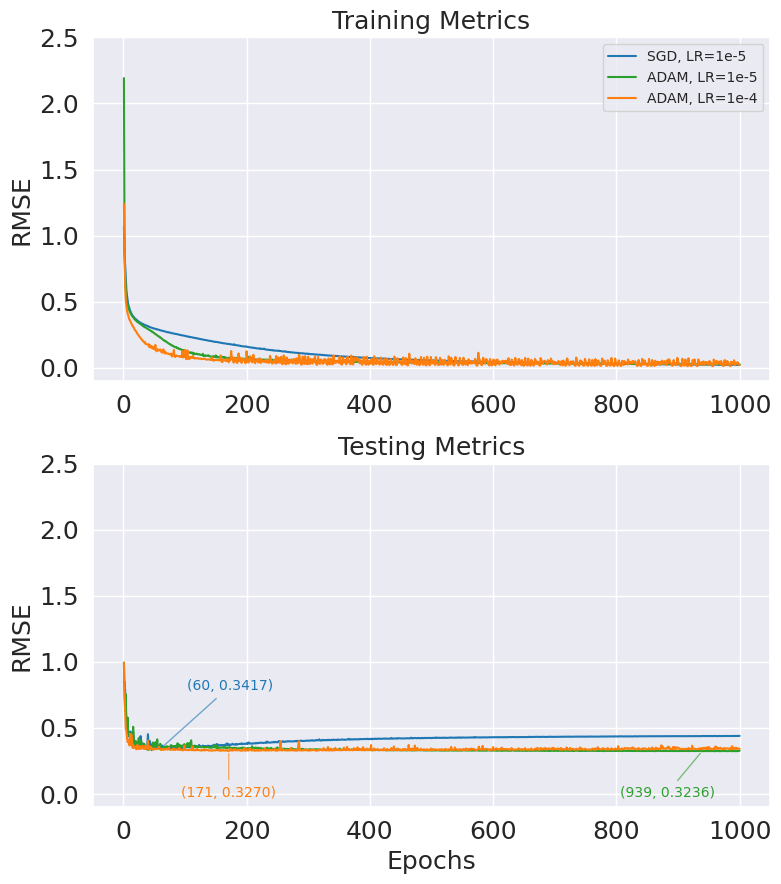

In [370]:
e_sgd_lr_1e_neg_5 = "../../results/run_results/esm_gcn/sgd.lr1e-5.esm-gcn-DMS_OLD-expression-2024-11-15_19-11/esm-gcn-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
e_adam_lr_1e_neg_5 = "../../results/run_results/esm_gcn/adam.lr1e-5.esm_gcn-DMS_OLD-expression-2024-11-23_21-45/esm_gcn-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
e_adam_lr_1e_neg_4 = "../../results/run_results/esm_gcn/adam.lr1e-4.esm_gcn-DMS_OLD-expression-2024-11-25_15-55/esm_gcn-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
comparison_file = "../../results/plots/model_comparisons/finetuning/esm_gcn.expression"
plot_comparative_lr_log_file(e_sgd_lr_1e_neg_5,e_adam_lr_1e_neg_5, e_adam_lr_1e_neg_4, f"{comparison_file}.model_comp.pdf")

--- 
### ESM-BLSTM

Best test RMSE at epoch x:
SGD, LR=1e-5: epoch 69, rmse 0.5656
ADAM, LR=1e-5: epoch 325, rmse 0.5230
ADAM, LR=1e-4: epoch 49, rmse 0.5612


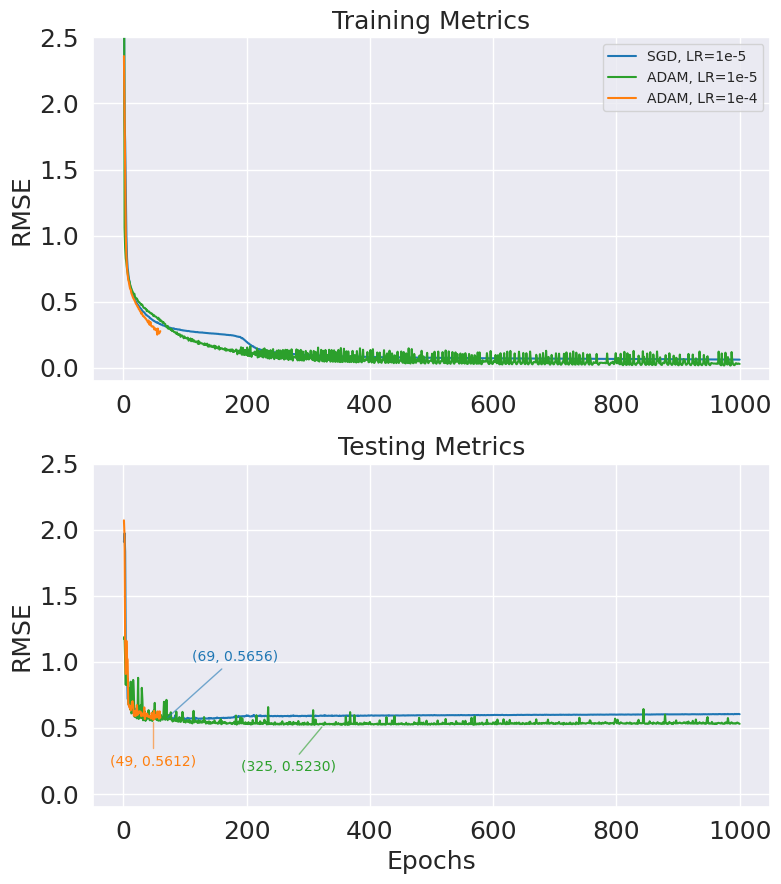

In [371]:
b_sgd_lr_1e_neg_5 = "../../results/run_results/esm_blstm/sgd.lr1e-5.esm_blstm-DMS_OLD-binding-2024-11-23_21-54/esm_blstm-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
b_adam_lr_1e_neg_5 = "../../results/run_results/esm_blstm/adam.lr1e-5.esm_blstm-DMS_OLD-binding-2024-11-23_22-05/esm_blstm-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
b_adam_lr_1e_neg_4 = "../../results/run_results/esm_blstm/adam.lr1e-4.esm_blstm-DMS_OLD-binding-2024-11-26_08-29/esm_blstm-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
comparison_file = "../../results/plots/model_comparisons/finetuning/esm_blstm.binding"
plot_comparative_lr_log_file(b_sgd_lr_1e_neg_5,b_adam_lr_1e_neg_5, b_adam_lr_1e_neg_4, f"{comparison_file}.model_comp.pdf")

Best test RMSE at epoch x:
SGD, LR=1e-5: epoch 72, rmse 0.3391
ADAM, LR=1e-5: epoch 40, rmse 0.3284
ADAM, LR=1e-4: epoch 56, rmse 0.3365


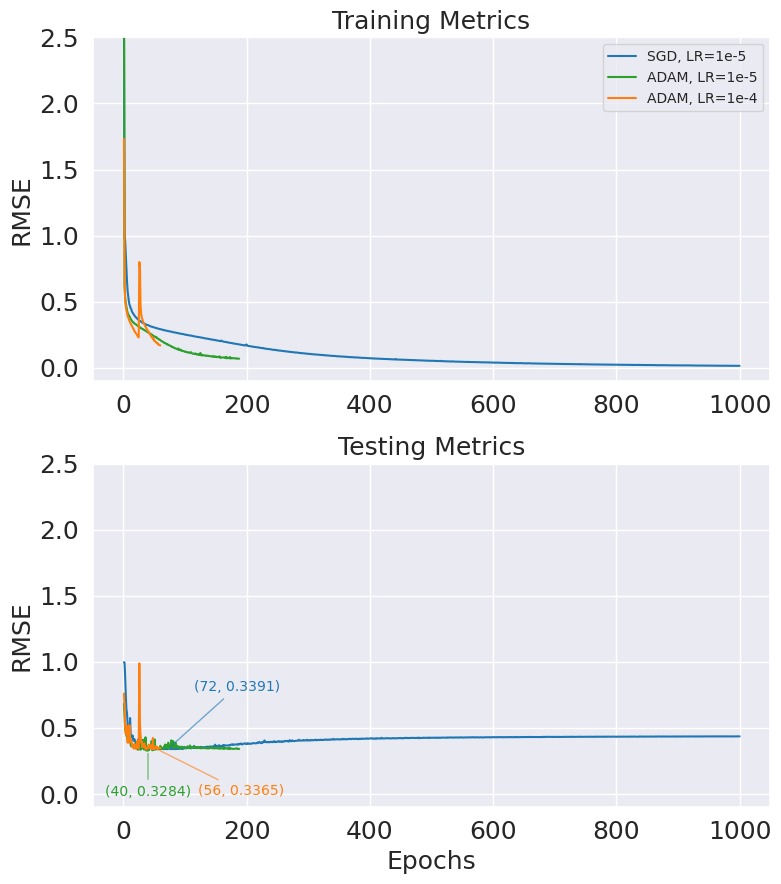

In [372]:
def plot_comparative_lr_log_file(metrics_csv_1, metrics_csv_2, metrics_csv_3, metrics_img):
    df1 = pd.read_csv(metrics_csv_1)
    df2 = pd.read_csv(metrics_csv_2)
    df3 = pd.read_csv(metrics_csv_3)

    sns.set_theme(style="darkgrid")
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 9))  # 2 rows, 1 column
    fontsize = 18

    # Plot 1: Training Metrics (binding, expression)
    ax1.plot(df1['Epoch'], df1['Train RMSE'], label='SGD, LR=1e-5', color='tab:blue', linestyle='-', linewidth=1.5)
    ax1.plot(df2['Epoch'], df2['Train RMSE'], label='ADAM, LR=1e-5', color='tab:green', linestyle='-', linewidth=1.5)
    ax1.plot(df3['Epoch'], df3['Train RMSE'], label='ADAM, LR=1e-4', color='tab:orange', linestyle='-', linewidth=1.5)

    ax1.tick_params(axis='x', labelsize=fontsize)    
    ax1.set_xlim(-50, 1050)
    ax1.set_ylabel('RMSE', fontsize=fontsize)
    ax1.tick_params(axis='y', labelsize=fontsize)
    ax1.set_ylim(-0.1, 2.5)
    ax1.legend(loc='upper right', fontsize=fontsize-8)
    ax1.set_title('Training Metrics', fontsize=fontsize)

    # Plot Best Test Loss
    best_df1_rmse = find_best_epoch(metrics_csv_1, 'Test RMSE')
    best_df2_rmse = find_best_epoch(metrics_csv_2, 'Test RMSE')
    best_df3_rmse = find_best_epoch(metrics_csv_3, 'Test RMSE')
    
    print("Best test RMSE at epoch x:")
    print(f"SGD, LR=1e-5: epoch {best_df1_rmse[0]}, rmse {best_df1_rmse[1]:.4f}")
    print(f"ADAM, LR=1e-5: epoch {best_df2_rmse[0]}, rmse {best_df2_rmse[1]:.4f}")
    print(f"ADAM, LR=1e-4: epoch {best_df3_rmse[0]}, rmse {best_df3_rmse[1]:.4f}")

    ax2.annotate(
        f'({best_df1_rmse[0]}, {best_df1_rmse[1]:.4f})', best_df1_rmse, 
        textcoords="offset points", xytext=(50,50), ha='center', va='top', color='tab:blue', fontsize=fontsize-8,
        arrowprops=dict(arrowstyle="-", color='tab:blue', lw=1, alpha=0.6)
    )
    ax2.annotate(
        f'({best_df2_rmse[0]}, {best_df2_rmse[1]:.4f})', best_df2_rmse, 
        textcoords="offset points", xytext=(0,-25), ha='center', va='top', color='tab:green', fontsize=fontsize-8,
        arrowprops=dict(arrowstyle="-", color='tab:green', lw=1, alpha=0.6)
    )
    ax2.annotate(
        f'({best_df3_rmse[0]}, {best_df3_rmse[1]:.4f})', best_df3_rmse, 
        textcoords="offset points", xytext=(60,-25), ha='center', va='top', color='tab:orange', fontsize=fontsize-8,
        arrowprops=dict(arrowstyle="-", color='tab:orange', lw=1, alpha=0.6)
    )

    # Plot 2: Testing Metrics (binding, expression)
    ax2.plot(df1['Epoch'], df1['Test RMSE'], label='SGD, LR=1e-5', color='tab:blue', linestyle='-', linewidth=1.5)
    ax2.plot(df2['Epoch'], df2['Test RMSE'], label='ADAM, LR=1e-5', color='tab:green', linestyle='-', linewidth=1.5)
    ax2.plot(df3['Epoch'], df3['Test RMSE'], label='ADAM, LR=1e-4', color='tab:orange', linestyle='-', linewidth=1.5)

    ax2.set_xlabel('Epochs', fontsize=fontsize)
    ax2.tick_params(axis='x', labelsize=fontsize)
    ax2.set_xlim(-50, 1050)
    ax2.set_ylabel('RMSE', fontsize=fontsize)
    ax2.tick_params(axis='y', labelsize=fontsize)
    ax2.set_ylim(-0.1, 2.5)
    ax2.set_title('Testing Metrics', fontsize=fontsize)

    plt.tight_layout()
    plt.savefig(metrics_img, format='pdf')
    plt.savefig(metrics_img.replace('.pdf', '.png'), format='png')

e_sgd_lr_1e_neg_5 = "../../results/run_results/esm_blstm/sgd.lr1e-5.esm_blstm-DMS_OLD-expression-2024-10-22_14-39/esm_blstm-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
e_adam_lr_1e_neg_5 = "../../results/run_results/esm_blstm/adam.lr1e-5.esm_blstm-DMS_OLD-expression-2024-11-26_01-54/esm_blstm-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
e_adam_lr_1e_neg_4 = "../../results/run_results/esm_blstm/adam.lr1e-4.esm_blstm-DMS_OLD-expression-2024-11-26_08-28/esm_blstm-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
comparison_file = "../../results/plots/model_comparisons/finetuning/esm_blstm.expression"
plot_comparative_lr_log_file(e_sgd_lr_1e_neg_5,e_adam_lr_1e_neg_5, e_adam_lr_1e_neg_4, f"{comparison_file}.model_comp.pdf")

---
### ESM-BLSTM w/ Finetuned BERT_MLM_ESM_INIT

Best test RMSE at epoch x:
SGD, LR=1e-5: epoch 92, rmse 0.6581
ADAM, LR=1e-5: epoch 92, rmse 0.6581
ADAM, LR=1e-4: epoch 58, rmse 0.5883


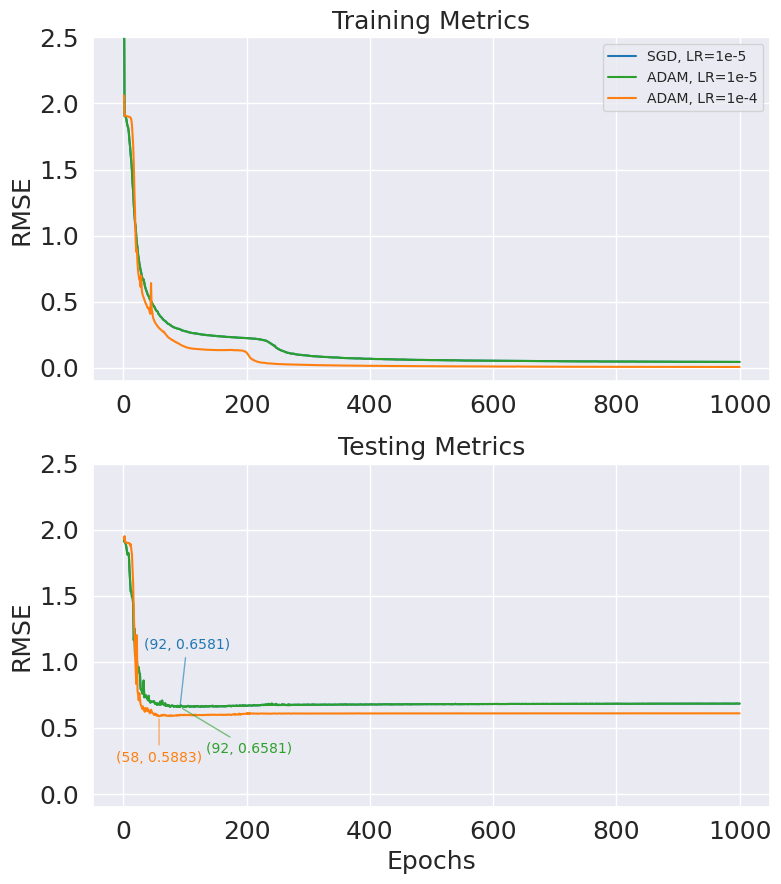

In [373]:
def plot_comparative_lr_log_file(metrics_csv_1, metrics_csv_2, metrics_csv_3, metrics_img):
    df1 = pd.read_csv(metrics_csv_1)
    df2 = pd.read_csv(metrics_csv_2)
    df3 = pd.read_csv(metrics_csv_3)

    sns.set_theme(style="darkgrid")
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 9))  # 2 rows, 1 column
    fontsize = 18

    # Plot 1: Training Metrics (binding, expression)
    ax1.plot(df1['Epoch'], df1['Train RMSE'], label='SGD, LR=1e-5', color='tab:blue', linestyle='-', linewidth=1.5)
    ax1.plot(df2['Epoch'], df2['Train RMSE'], label='ADAM, LR=1e-5', color='tab:green', linestyle='-', linewidth=1.5)
    ax1.plot(df3['Epoch'], df3['Train RMSE'], label='ADAM, LR=1e-4', color='tab:orange', linestyle='-', linewidth=1.5)

    ax1.tick_params(axis='x', labelsize=fontsize)    
    ax1.set_xlim(-50, 1050)
    ax1.set_ylabel('RMSE', fontsize=fontsize)
    ax1.tick_params(axis='y', labelsize=fontsize)
    ax1.set_ylim(-0.1, 2.5)
    ax1.legend(loc='upper right', fontsize=fontsize-8)
    ax1.set_title('Training Metrics', fontsize=fontsize)

    # Plot Best Test Loss
    best_df1_rmse = find_best_epoch(metrics_csv_1, 'Test RMSE')
    best_df2_rmse = find_best_epoch(metrics_csv_2, 'Test RMSE')
    best_df3_rmse = find_best_epoch(metrics_csv_3, 'Test RMSE')
    
    print("Best test RMSE at epoch x:")
    print(f"SGD, LR=1e-5: epoch {best_df1_rmse[0]}, rmse {best_df1_rmse[1]:.4f}")
    print(f"ADAM, LR=1e-5: epoch {best_df2_rmse[0]}, rmse {best_df2_rmse[1]:.4f}")
    print(f"ADAM, LR=1e-4: epoch {best_df3_rmse[0]}, rmse {best_df3_rmse[1]:.4f}")

    ax2.annotate(
        f'({best_df1_rmse[0]}, {best_df1_rmse[1]:.4f})', best_df1_rmse, 
        textcoords="offset points", xytext=(5,50), ha='center', va='top', color='tab:blue', fontsize=fontsize-8,
        arrowprops=dict(arrowstyle="-", color='tab:blue', lw=1, alpha=0.6)
    )
    ax2.annotate(
        f'({best_df2_rmse[0]}, {best_df2_rmse[1]:.4f})', best_df2_rmse, 
        textcoords="offset points", xytext=(50,-25), ha='center', va='top', color='tab:green', fontsize=fontsize-8,
        arrowprops=dict(arrowstyle="-", color='tab:green', lw=1, alpha=0.6)
    )
    ax2.annotate(
        f'({best_df3_rmse[0]}, {best_df3_rmse[1]:.4f})', best_df3_rmse, 
        textcoords="offset points", xytext=(0,-25), ha='center', va='top', color='tab:orange', fontsize=fontsize-8,
        arrowprops=dict(arrowstyle="-", color='tab:orange', lw=1, alpha=0.6)
    )

    # Plot 2: Testing Metrics (binding, expression)
    ax2.plot(df1['Epoch'], df1['Test RMSE'], label='SGD, LR=1e-5', color='tab:blue', linestyle='-', linewidth=1.5)
    ax2.plot(df2['Epoch'], df2['Test RMSE'], label='ADAM, LR=1e-5', color='tab:green', linestyle='-', linewidth=1.5)
    ax2.plot(df3['Epoch'], df3['Test RMSE'], label='ADAM, LR=1e-4', color='tab:orange', linestyle='-', linewidth=1.5)

    ax2.set_xlabel('Epochs', fontsize=fontsize)
    ax2.tick_params(axis='x', labelsize=fontsize)
    ax2.set_xlim(-50, 1050)
    ax2.set_ylabel('RMSE', fontsize=fontsize)
    ax2.tick_params(axis='y', labelsize=fontsize)
    ax2.set_ylim(-0.1, 2.5)
    ax2.set_title('Testing Metrics', fontsize=fontsize)

    plt.tight_layout()
    plt.savefig(metrics_img, format='pdf')
    plt.savefig(metrics_img.replace('.pdf', '.png'), format='png')

b_sgd_lr_1e_neg_5 = "../../results/run_results/esm_blstm-bert_mlm_esm_init/sgd.lr1e-5.esm_blstm-bert_mlm_esm_init-DMS_OLD-binding-2024-11-21_10-34/esm_blstm-bert_mlm_esm_init-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
b_adam_lr_1e_neg_5 = "../../results/run_results/esm_blstm-bert_mlm_esm_init/adam.lr1e-5.esm_blstm-bert_mlm_esm_init-DMS_OLD-binding-2024-11-21_10-35/esm_blstm-bert_mlm_esm_init-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
b_adam_lr_1e_neg_4 = "../../results/run_results/esm_blstm-bert_mlm_esm_init/adam.lr1e-4.esm_blstm-bert_mlm_esm_init-DMS_OLD-binding-2024-11-21_10-38/esm_blstm-bert_mlm_esm_init-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
comparison_file = "../../results/plots/model_comparisons/finetuning/esm_blstm-bert_mlm_esm_init.binding"
plot_comparative_lr_log_file(b_sgd_lr_1e_neg_5,b_adam_lr_1e_neg_5, b_adam_lr_1e_neg_4, f"{comparison_file}.model_comp.pdf")

Best test RMSE at epoch x:
SGD, LR=1e-5: epoch 109, rmse 0.3784
ADAM, LR=1e-5: epoch 109, rmse 0.3784
ADAM, LR=1e-4: epoch 61, rmse 0.3789


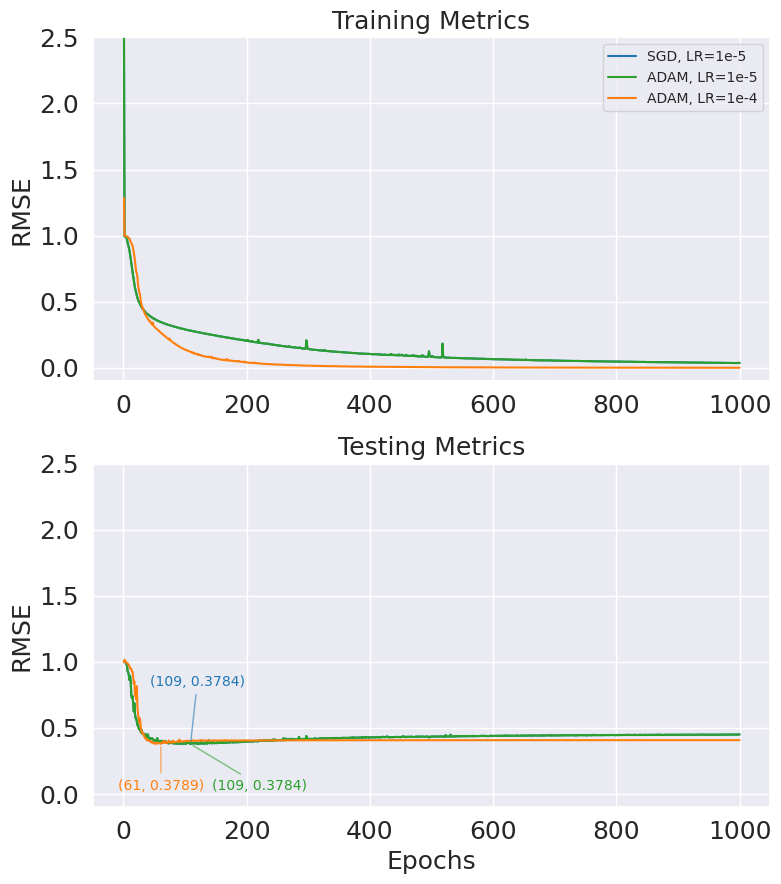

In [374]:
e_sgd_lr_1e_neg_5 = "../../results/run_results/esm_blstm-bert_mlm_esm_init/sgd.lr1e-5.esm_blstm-bert_mlm_esm_init-DMS_OLD-expression-2024-11-21_10-34/esm_blstm-bert_mlm_esm_init-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
e_adam_lr_1e_neg_5 = "../../results/run_results/esm_blstm-bert_mlm_esm_init/adam.lr1e-5.esm_blstm-bert_mlm_esm_init-DMS_OLD-expression-2024-11-21_10-36/esm_blstm-bert_mlm_esm_init-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
e_adam_lr_1e_neg_4 = "../../results/run_results/esm_blstm-bert_mlm_esm_init/adam.lr1e-4.esm_blstm-bert_mlm_esm_init-DMS_OLD-expression-2024-11-21_10-38/esm_blstm-bert_mlm_esm_init-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
comparison_file = "../../results/plots/model_comparisons/finetuning/esm_blstm-bert_mlm_esm_init.expression"
plot_comparative_lr_log_file(e_sgd_lr_1e_neg_5,e_adam_lr_1e_neg_5, e_adam_lr_1e_neg_4, f"{comparison_file}.model_comp.pdf")

---
### FCN ESM-CLS Preembedded

Best test RMSE at epoch x:
SGD, LR=1e-5: epoch 976, rmse 1.2884
ADAM, LR=1e-5: epoch 929, rmse 1.2137
ADAM, LR=1e-4: epoch 272, rmse 1.2802


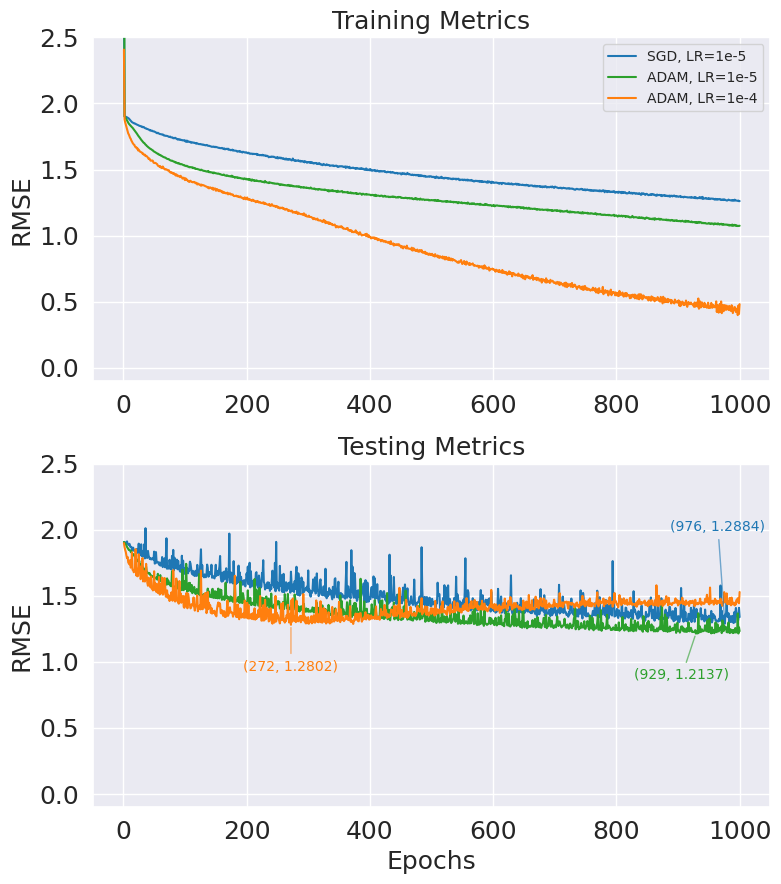

In [375]:
def plot_comparative_lr_log_file(metrics_csv_1, metrics_csv_2, metrics_csv_3, metrics_img):
    df1 = pd.read_csv(metrics_csv_1)
    df2 = pd.read_csv(metrics_csv_2)
    df3 = pd.read_csv(metrics_csv_3)

    sns.set_theme(style="darkgrid")
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 9))  # 2 rows, 1 column
    fontsize = 18

    # Plot 1: Training Metrics (binding, expression)
    ax1.plot(df1['Epoch'], df1['Train RMSE'], label='SGD, LR=1e-5', color='tab:blue', linestyle='-', linewidth=1.5)
    ax1.plot(df2['Epoch'], df2['Train RMSE'], label='ADAM, LR=1e-5', color='tab:green', linestyle='-', linewidth=1.5)
    ax1.plot(df3['Epoch'], df3['Train RMSE'], label='ADAM, LR=1e-4', color='tab:orange', linestyle='-', linewidth=1.5)

    ax1.tick_params(axis='x', labelsize=fontsize)    
    ax1.set_xlim(-50, 1050)
    ax1.set_ylabel('RMSE', fontsize=fontsize)
    ax1.tick_params(axis='y', labelsize=fontsize)
    ax1.set_ylim(-0.1, 2.5)
    ax1.legend(loc='upper right', fontsize=fontsize-8)
    ax1.set_title('Training Metrics', fontsize=fontsize)

    # Plot Best Test Loss
    best_df1_rmse = find_best_epoch(metrics_csv_1, 'Test RMSE')
    best_df2_rmse = find_best_epoch(metrics_csv_2, 'Test RMSE')
    best_df3_rmse = find_best_epoch(metrics_csv_3, 'Test RMSE')
    
    print("Best test RMSE at epoch x:")
    print(f"SGD, LR=1e-5: epoch {best_df1_rmse[0]}, rmse {best_df1_rmse[1]:.4f}")
    print(f"ADAM, LR=1e-5: epoch {best_df2_rmse[0]}, rmse {best_df2_rmse[1]:.4f}")
    print(f"ADAM, LR=1e-4: epoch {best_df3_rmse[0]}, rmse {best_df3_rmse[1]:.4f}")

    ax2.annotate(
        f'({best_df1_rmse[0]}, {best_df1_rmse[1]:.4f})', best_df1_rmse, 
        textcoords="offset points", xytext=(-5,75), ha='center', va='top', color='tab:blue', fontsize=fontsize-8,
        arrowprops=dict(arrowstyle="-", color='tab:blue', lw=1, alpha=0.6)
    )
    ax2.annotate(
        f'({best_df2_rmse[0]}, {best_df2_rmse[1]:.4f})', best_df2_rmse, 
        textcoords="offset points", xytext=(-10,-25), ha='center', va='top', color='tab:green', fontsize=fontsize-8,
        arrowprops=dict(arrowstyle="-", color='tab:green', lw=1, alpha=0.6)
    )
    ax2.annotate(
        f'({best_df3_rmse[0]}, {best_df3_rmse[1]:.4f})', best_df3_rmse, 
        textcoords="offset points", xytext=(0,-25), ha='center', va='top', color='tab:orange', fontsize=fontsize-8,
        arrowprops=dict(arrowstyle="-", color='tab:orange', lw=1, alpha=0.6)
    )

    # Plot 2: Testing Metrics (binding, expression)
    ax2.plot(df1['Epoch'], df1['Test RMSE'], label='SGD, LR=1e-5', color='tab:blue', linestyle='-', linewidth=1.5)
    ax2.plot(df2['Epoch'], df2['Test RMSE'], label='ADAM, LR=1e-5', color='tab:green', linestyle='-', linewidth=1.5)
    ax2.plot(df3['Epoch'], df3['Test RMSE'], label='ADAM, LR=1e-4', color='tab:orange', linestyle='-', linewidth=1.5)

    ax2.set_xlabel('Epochs', fontsize=fontsize)
    ax2.tick_params(axis='x', labelsize=fontsize)
    ax2.set_xlim(-50, 1050)
    ax2.set_ylabel('RMSE', fontsize=fontsize)
    ax2.tick_params(axis='y', labelsize=fontsize)
    ax2.set_ylim(-0.1, 2.5)
    ax2.set_title('Testing Metrics', fontsize=fontsize)

    plt.tight_layout()
    plt.savefig(metrics_img, format='pdf')
    plt.savefig(metrics_img.replace('.pdf', '.png'), format='png')

b_sgd_lr_1e_neg_5 = "../../results/run_results/fcn-ESM_CLS_preembedded/sgd.lr1e-5.fcn-ESM_CLS_preembedded-DMS_OLD-binding-2024-11-14_02-07/fcn-ESM_CLS_preembedded-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
b_adam_lr_1e_neg_5 = "../../results/run_results/fcn-ESM_CLS_preembedded/adam.lr1e-5.fcn-ESM_CLS_preembedded-DMS_OLD-binding-2024-11-15_17-49/fcn-ESM_CLS_preembedded-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
b_adam_lr_1e_neg_4 = "../../results/run_results/fcn-ESM_CLS_preembedded/adam.lr1e-4.fcn-ESM_CLS_preembedded-DMS_OLD-binding-2024-11-21_10-22/fcn-ESM_CLS_preembedded-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
comparison_file = "../../results/plots/model_comparisons/finetuning/fcn-esm_cls_preembedded.binding"
plot_comparative_lr_log_file(b_sgd_lr_1e_neg_5,b_adam_lr_1e_neg_5, b_adam_lr_1e_neg_4, f"{comparison_file}.model_comp.pdf")

Best test RMSE at epoch x:
SGD, LR=1e-5: epoch 973, rmse 0.6697
ADAM, LR=1e-5: epoch 991, rmse 0.6180
ADAM, LR=1e-4: epoch 460, rmse 0.6579


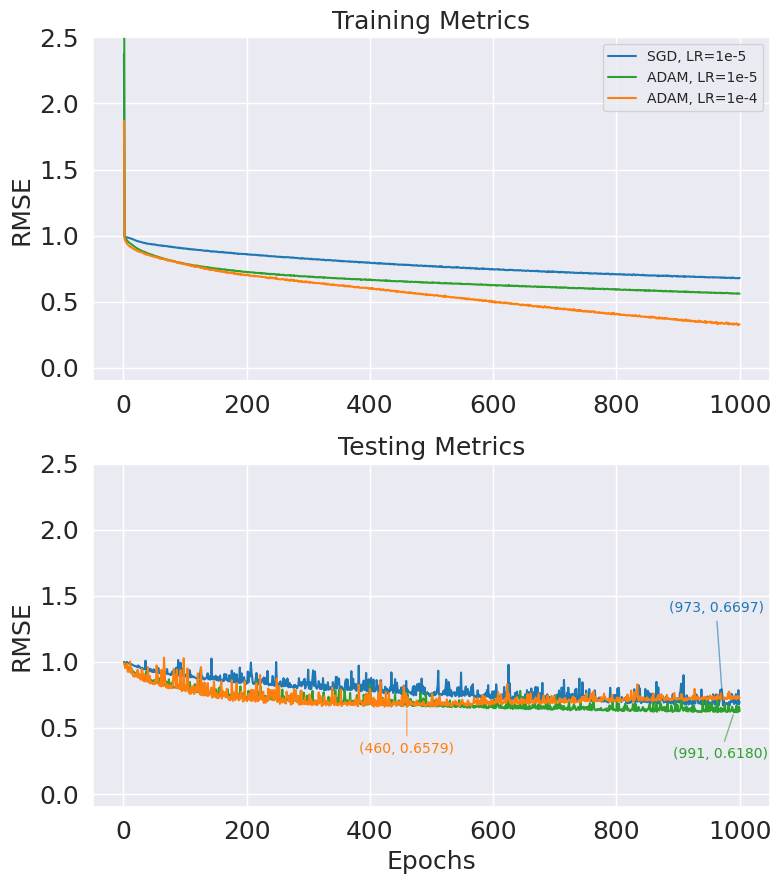

In [376]:
e_sgd_lr_1e_neg_5 = "../../results/run_results/fcn-ESM_CLS_preembedded/sgd.lr1e-5.fcn-ESM_CLS_preembedded-DMS_OLD-expression-2024-11-14_02-06/fcn-ESM_CLS_preembedded-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
e_adam_lr_1e_neg_5 = "../../results/run_results/fcn-ESM_CLS_preembedded/adam.lr1e-5.fcn-ESM_CLS_preembedded-DMS_OLD-expression-2024-11-15_17-58/fcn-ESM_CLS_preembedded-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
e_adam_lr_1e_neg_4 = "../../results/run_results/fcn-ESM_CLS_preembedded/adam.lr1e-4.fcn-ESM_CLS_preembedded-DMS_OLD-expression-2024-11-21_10-23/fcn-ESM_CLS_preembedded-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
comparison_file = "../../results/plots/model_comparisons/finetuning/fcn-esm_cls_preembedded.expression"
plot_comparative_lr_log_file(e_sgd_lr_1e_neg_5,e_adam_lr_1e_neg_5, e_adam_lr_1e_neg_4, f"{comparison_file}.model_comp.pdf")

---
### BLSTM ESM-AA Preembedded

Best test RMSE at epoch x:
SGD, LR=1e-5: epoch 980, rmse 0.6044
ADAM, LR=1e-5: epoch 864, rmse 0.5988
ADAM, LR=1e-4: epoch 864, rmse 0.5988


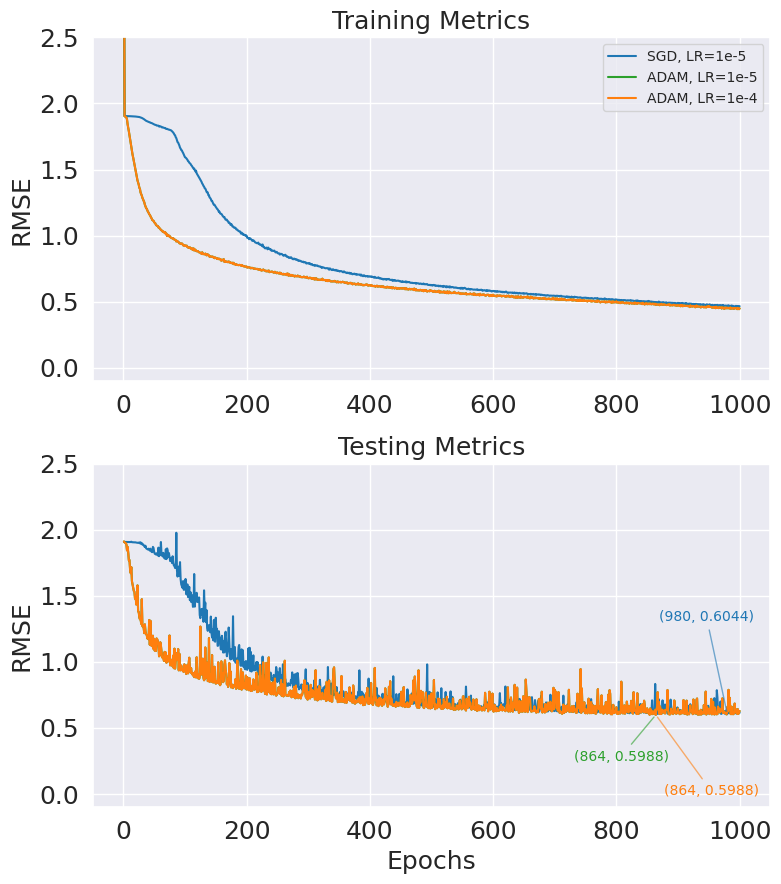

In [377]:
def plot_comparative_lr_log_file(metrics_csv_1, metrics_csv_2, metrics_csv_3, metrics_img):
    df1 = pd.read_csv(metrics_csv_1)
    df2 = pd.read_csv(metrics_csv_2)
    df3 = pd.read_csv(metrics_csv_3)

    sns.set_theme(style="darkgrid")
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 9))  # 2 rows, 1 column
    fontsize = 18

    # Plot 1: Training Metrics (binding, expression)
    ax1.plot(df1['Epoch'], df1['Train RMSE'], label='SGD, LR=1e-5', color='tab:blue', linestyle='-', linewidth=1.5)
    ax1.plot(df2['Epoch'], df2['Train RMSE'], label='ADAM, LR=1e-5', color='tab:green', linestyle='-', linewidth=1.5)
    ax1.plot(df3['Epoch'], df3['Train RMSE'], label='ADAM, LR=1e-4', color='tab:orange', linestyle='-', linewidth=1.5)

    ax1.tick_params(axis='x', labelsize=fontsize)    
    ax1.set_xlim(-50, 1050)
    ax1.set_ylabel('RMSE', fontsize=fontsize)
    ax1.tick_params(axis='y', labelsize=fontsize)
    ax1.set_ylim(-0.1, 2.5)
    ax1.legend(loc='upper right', fontsize=fontsize-8)
    ax1.set_title('Training Metrics', fontsize=fontsize)

    # Plot Best Test Loss
    best_df1_rmse = find_best_epoch(metrics_csv_1, 'Test RMSE')
    best_df2_rmse = find_best_epoch(metrics_csv_2, 'Test RMSE')
    best_df3_rmse = find_best_epoch(metrics_csv_3, 'Test RMSE')
    
    print("Best test RMSE at epoch x:")
    print(f"SGD, LR=1e-5: epoch {best_df1_rmse[0]}, rmse {best_df1_rmse[1]:.4f}")
    print(f"ADAM, LR=1e-5: epoch {best_df2_rmse[0]}, rmse {best_df2_rmse[1]:.4f}")
    print(f"ADAM, LR=1e-4: epoch {best_df3_rmse[0]}, rmse {best_df3_rmse[1]:.4f}")

    ax2.annotate(
        f'({best_df1_rmse[0]}, {best_df1_rmse[1]:.4f})', best_df1_rmse, 
        textcoords="offset points", xytext=(-15,75), ha='center', va='top', color='tab:blue', fontsize=fontsize-8,
        arrowprops=dict(arrowstyle="-", color='tab:blue', lw=1, alpha=0.6)
    )
    ax2.annotate(
        f'({best_df2_rmse[0]}, {best_df2_rmse[1]:.4f})', best_df2_rmse, 
        textcoords="offset points", xytext=(-25,-25), ha='center', va='top', color='tab:green', fontsize=fontsize-8,
        arrowprops=dict(arrowstyle="-", color='tab:green', lw=1, alpha=0.6)
    )
    ax2.annotate(
        f'({best_df3_rmse[0]}, {best_df3_rmse[1]:.4f})', best_df3_rmse, 
        textcoords="offset points", xytext=(40,-50), ha='center', va='top', color='tab:orange', fontsize=fontsize-8,
        arrowprops=dict(arrowstyle="-", color='tab:orange', lw=1, alpha=0.6)
    )

    # Plot 2: Testing Metrics (binding, expression)
    ax2.plot(df1['Epoch'], df1['Test RMSE'], label='SGD, LR=1e-5', color='tab:blue', linestyle='-', linewidth=1.5)
    ax2.plot(df2['Epoch'], df2['Test RMSE'], label='ADAM, LR=1e-5', color='tab:green', linestyle='-', linewidth=1.5)
    ax2.plot(df3['Epoch'], df3['Test RMSE'], label='ADAM, LR=1e-4', color='tab:orange', linestyle='-', linewidth=1.5)

    ax2.set_xlabel('Epochs', fontsize=fontsize)
    ax2.tick_params(axis='x', labelsize=fontsize)
    ax2.set_xlim(-50, 1050)
    ax2.set_ylabel('RMSE', fontsize=fontsize)
    ax2.tick_params(axis='y', labelsize=fontsize)
    ax2.set_ylim(-0.1, 2.5)
    ax2.set_title('Testing Metrics', fontsize=fontsize)

    plt.tight_layout()
    plt.savefig(metrics_img, format='pdf')
    plt.savefig(metrics_img.replace('.pdf', '.png'), format='png')

b_sgd_lr_1e_neg_5 = "../../results/run_results/blstm-ESM_AA_preembedded/sgd.lr1e-5.blstm-ESM_AA_preembedded-DMS_OLD-binding-2024-11-12_21-02/blstm-ESM_AA_preembedded-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
b_adam_lr_1e_neg_5 = "../../results/run_results/blstm-ESM_AA_preembedded/adam.lr1e-5.blstm-ESM_AA_preembedded-DMS_OLD-binding-2024-11-15_18-40/blstm-ESM_AA_preembedded-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
b_adam_lr_1e_neg_4 = "../../results/run_results/blstm-ESM_AA_preembedded/adam.lr1e-4.blstm-ESM_AA_preembedded-DMS_OLD-binding-2024-11-21_16-58/blstm-ESM_AA_preembedded-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
comparison_file = "../../results/plots/model_comparisons/finetuning/blstm-esm_aa_preembedded.binding"
plot_comparative_lr_log_file(b_sgd_lr_1e_neg_5,b_adam_lr_1e_neg_5, b_adam_lr_1e_neg_4, f"{comparison_file}.model_comp.pdf")

Best test RMSE at epoch x:
SGD, LR=1e-5: epoch 995, rmse 0.4138
ADAM, LR=1e-5: epoch 952, rmse 0.3603
ADAM, LR=1e-4: epoch 952, rmse 0.3603


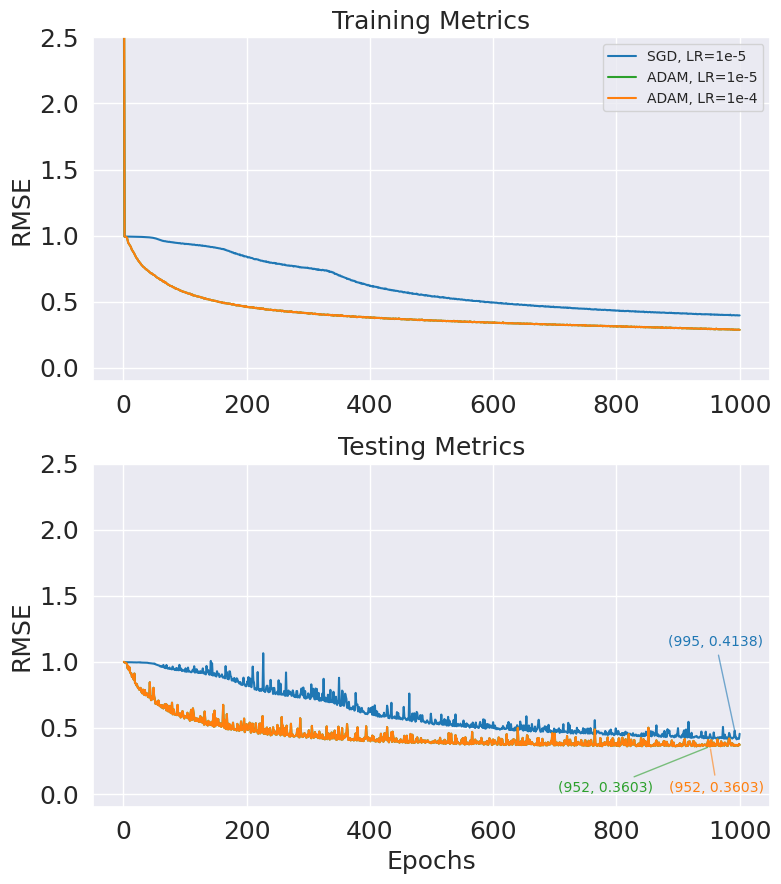

In [378]:
def plot_comparative_lr_log_file(metrics_csv_1, metrics_csv_2, metrics_csv_3, metrics_img):
    df1 = pd.read_csv(metrics_csv_1)
    df2 = pd.read_csv(metrics_csv_2)
    df3 = pd.read_csv(metrics_csv_3)

    sns.set_theme(style="darkgrid")
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 9))  # 2 rows, 1 column
    fontsize = 18

    # Plot 1: Training Metrics (binding, expression)
    ax1.plot(df1['Epoch'], df1['Train RMSE'], label='SGD, LR=1e-5', color='tab:blue', linestyle='-', linewidth=1.5)
    ax1.plot(df2['Epoch'], df2['Train RMSE'], label='ADAM, LR=1e-5', color='tab:green', linestyle='-', linewidth=1.5)
    ax1.plot(df3['Epoch'], df3['Train RMSE'], label='ADAM, LR=1e-4', color='tab:orange', linestyle='-', linewidth=1.5)

    ax1.tick_params(axis='x', labelsize=fontsize)    
    ax1.set_xlim(-50, 1050)
    ax1.set_ylabel('RMSE', fontsize=fontsize)
    ax1.tick_params(axis='y', labelsize=fontsize)
    ax1.set_ylim(-0.1, 2.5)
    ax1.legend(loc='upper right', fontsize=fontsize-8)
    ax1.set_title('Training Metrics', fontsize=fontsize)

    # Plot Best Test Loss
    best_df1_rmse = find_best_epoch(metrics_csv_1, 'Test RMSE')
    best_df2_rmse = find_best_epoch(metrics_csv_2, 'Test RMSE')
    best_df3_rmse = find_best_epoch(metrics_csv_3, 'Test RMSE')
    
    print("Best test RMSE at epoch x:")
    print(f"SGD, LR=1e-5: epoch {best_df1_rmse[0]}, rmse {best_df1_rmse[1]:.4f}")
    print(f"ADAM, LR=1e-5: epoch {best_df2_rmse[0]}, rmse {best_df2_rmse[1]:.4f}")
    print(f"ADAM, LR=1e-4: epoch {best_df3_rmse[0]}, rmse {best_df3_rmse[1]:.4f}")

    ax2.annotate(
        f'({best_df1_rmse[0]}, {best_df1_rmse[1]:.4f})', best_df1_rmse, 
        textcoords="offset points", xytext=(-15,75), ha='center', va='top', color='tab:blue', fontsize=fontsize-8,
        arrowprops=dict(arrowstyle="-", color='tab:blue', lw=1, alpha=0.6)
    )
    ax2.annotate(
        f'({best_df2_rmse[0]}, {best_df2_rmse[1]:.4f})', best_df2_rmse, 
        textcoords="offset points", xytext=(-75,-25), ha='center', va='top', color='tab:green', fontsize=fontsize-8,
        arrowprops=dict(arrowstyle="-", color='tab:green', lw=1, alpha=0.6)
    )
    ax2.annotate(
        f'({best_df3_rmse[0]}, {best_df3_rmse[1]:.4f})', best_df3_rmse, 
        textcoords="offset points", xytext=(5,-25), ha='center', va='top', color='tab:orange', fontsize=fontsize-8,
        arrowprops=dict(arrowstyle="-", color='tab:orange', lw=1, alpha=0.6)
    )

    # Plot 2: Testing Metrics (binding, expression)
    ax2.plot(df1['Epoch'], df1['Test RMSE'], label='SGD, LR=1e-5', color='tab:blue', linestyle='-', linewidth=1.5)
    ax2.plot(df2['Epoch'], df2['Test RMSE'], label='ADAM, LR=1e-5', color='tab:green', linestyle='-', linewidth=1.5)
    ax2.plot(df3['Epoch'], df3['Test RMSE'], label='ADAM, LR=1e-4', color='tab:orange', linestyle='-', linewidth=1.5)

    ax2.set_xlabel('Epochs', fontsize=fontsize)
    ax2.tick_params(axis='x', labelsize=fontsize)
    ax2.set_xlim(-50, 1050)
    ax2.set_ylabel('RMSE', fontsize=fontsize)
    ax2.tick_params(axis='y', labelsize=fontsize)
    ax2.set_ylim(-0.1, 2.5)
    ax2.set_title('Testing Metrics', fontsize=fontsize)

    plt.tight_layout()
    plt.savefig(metrics_img, format='pdf')
    plt.savefig(metrics_img.replace('.pdf', '.png'), format='png')

e_sgd_lr_1e_neg_5 = "../../results/run_results/blstm-ESM_AA_preembedded/sgd.lr1e-5.blstm-ESM_AA_preembedded-DMS_OLD-expression-2024-11-12_20-57/blstm-ESM_AA_preembedded-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
e_adam_lr_1e_neg_5 = "../../results/run_results/blstm-ESM_AA_preembedded/adam.lr1e-5.blstm-ESM_AA_preembedded-DMS_OLD-expression-2024-11-15_18-41/blstm-ESM_AA_preembedded-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
e_adam_lr_1e_neg_4 = "../../results/run_results/blstm-ESM_AA_preembedded/adam.lr1e-4.blstm-ESM_AA_preembedded-DMS_OLD-expression-2024-11-21_16-59/blstm-ESM_AA_preembedded-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
comparison_file = "../../results/plots/model_comparisons/finetuning/blstm-esm_aa_preembedded.expression"
plot_comparative_lr_log_file(e_sgd_lr_1e_neg_5,e_adam_lr_1e_neg_5, e_adam_lr_1e_neg_4, f"{comparison_file}.model_comp.pdf")

---
### BLSTM NLP Preembedded w/ Finetuned BERT_MLM_ESM_INIT

Best test RMSE at epoch x:
SGD, LR=1e-5: epoch 992, rmse 1.9044
ADAM, LR=1e-5: epoch 983, rmse 0.8833
ADAM, LR=1e-4: epoch 897, rmse 1.9049


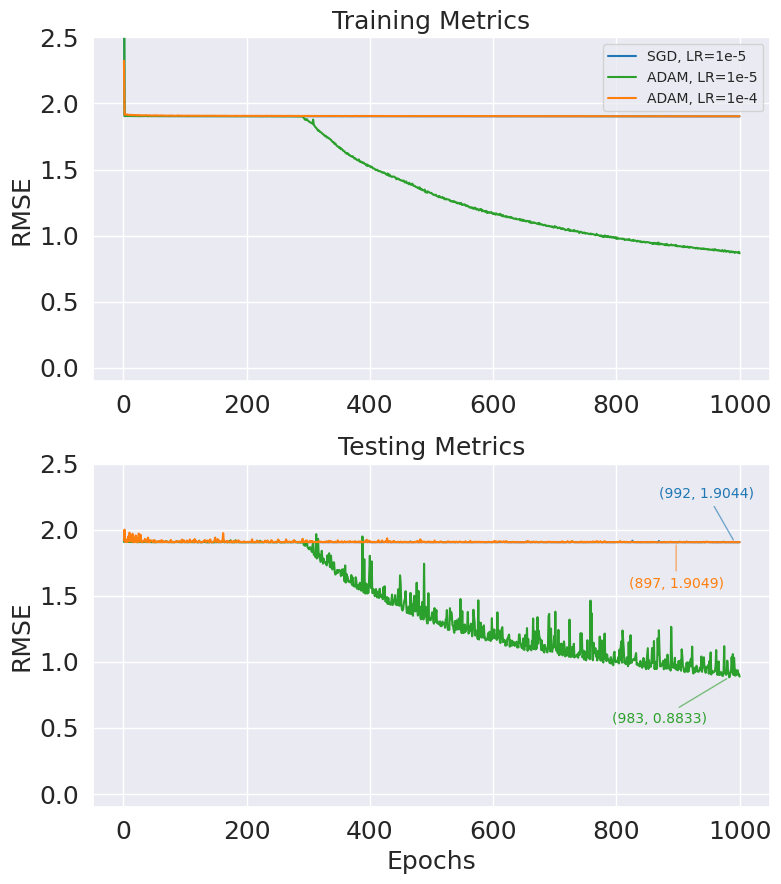

In [379]:
def plot_comparative_lr_log_file(metrics_csv_1, metrics_csv_2, metrics_csv_3, metrics_img):
    df1 = pd.read_csv(metrics_csv_1)
    df2 = pd.read_csv(metrics_csv_2)
    df3 = pd.read_csv(metrics_csv_3)

    sns.set_theme(style="darkgrid")
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 9))  # 2 rows, 1 column
    fontsize = 18

    # Plot 1: Training Metrics (binding, expression)
    ax1.plot(df1['Epoch'], df1['Train RMSE'], label='SGD, LR=1e-5', color='tab:blue', linestyle='-', linewidth=1.5)
    ax1.plot(df2['Epoch'], df2['Train RMSE'], label='ADAM, LR=1e-5', color='tab:green', linestyle='-', linewidth=1.5)
    ax1.plot(df3['Epoch'], df3['Train RMSE'], label='ADAM, LR=1e-4', color='tab:orange', linestyle='-', linewidth=1.5)

    ax1.tick_params(axis='x', labelsize=fontsize)    
    ax1.set_xlim(-50, 1050)
    ax1.set_ylabel('RMSE', fontsize=fontsize)
    ax1.tick_params(axis='y', labelsize=fontsize)
    ax1.set_ylim(-0.1, 2.5)
    ax1.legend(loc='upper right', fontsize=fontsize-8)
    ax1.set_title('Training Metrics', fontsize=fontsize)

    # Plot Best Test Loss
    best_df1_rmse = find_best_epoch(metrics_csv_1, 'Test RMSE')
    best_df2_rmse = find_best_epoch(metrics_csv_2, 'Test RMSE')
    best_df3_rmse = find_best_epoch(metrics_csv_3, 'Test RMSE')
    
    print("Best test RMSE at epoch x:")
    print(f"SGD, LR=1e-5: epoch {best_df1_rmse[0]}, rmse {best_df1_rmse[1]:.4f}")
    print(f"ADAM, LR=1e-5: epoch {best_df2_rmse[0]}, rmse {best_df2_rmse[1]:.4f}")
    print(f"ADAM, LR=1e-4: epoch {best_df3_rmse[0]}, rmse {best_df3_rmse[1]:.4f}")

    ax2.annotate(
        f'({best_df1_rmse[0]}, {best_df1_rmse[1]:.4f})', best_df1_rmse, 
        textcoords="offset points", xytext=(-20,40), ha='center', va='top', color='tab:blue', fontsize=fontsize-8,
        arrowprops=dict(arrowstyle="-", color='tab:blue', lw=1, alpha=0.6)
    )
    ax2.annotate(
        f'({best_df2_rmse[0]}, {best_df2_rmse[1]:.4f})', best_df2_rmse, 
        textcoords="offset points", xytext=(-50,-25), ha='center', va='top', color='tab:green', fontsize=fontsize-8,
        arrowprops=dict(arrowstyle="-", color='tab:green', lw=1, alpha=0.6)
    )
    ax2.annotate(
        f'({best_df3_rmse[0]}, {best_df3_rmse[1]:.4f})', best_df3_rmse, 
        textcoords="offset points", xytext=(0,-25), ha='center', va='top', color='tab:orange', fontsize=fontsize-8,
        arrowprops=dict(arrowstyle="-", color='tab:orange', lw=1, alpha=0.6)
    )

    # Plot 2: Testing Metrics (binding, expression)
    ax2.plot(df1['Epoch'], df1['Test RMSE'], label='SGD, LR=1e-5', color='tab:blue', linestyle='-', linewidth=1.5)
    ax2.plot(df2['Epoch'], df2['Test RMSE'], label='ADAM, LR=1e-5', color='tab:green', linestyle='-', linewidth=1.5)
    ax2.plot(df3['Epoch'], df3['Test RMSE'], label='ADAM, LR=1e-4', color='tab:orange', linestyle='-', linewidth=1.5)

    ax2.set_xlabel('Epochs', fontsize=fontsize)
    ax2.tick_params(axis='x', labelsize=fontsize)
    ax2.set_xlim(-50, 1050)
    ax2.set_ylabel('RMSE', fontsize=fontsize)
    ax2.tick_params(axis='y', labelsize=fontsize)
    ax2.set_ylim(-0.1, 2.5)
    ax2.set_title('Testing Metrics', fontsize=fontsize)

    plt.tight_layout()
    plt.savefig(metrics_img, format='pdf')
    plt.savefig(metrics_img.replace('.pdf', '.png'), format='png')

b_sgd_lr_1e_neg_5 = "../../results/run_results/blstm-NLP_preembedded/sgd.lr1e-5.blstm-NLP_preembedded-DMS_OLD-binding-2024-11-13_12-00/blstm-NLP_preembedded-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
b_adam_lr_1e_neg_5 = "../../results/run_results/blstm-NLP_preembedded/adam.lr1e-5.blstm-NLP_preembedded-DMS_OLD-binding-2024-11-15_23-16/blstm-NLP_preembedded-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
b_adam_lr_1e_neg_4 = "../../results/run_results/blstm-NLP_preembedded/adam.lr1e-4.blstm-NLP_preembedded-DMS_OLD-binding-2024-11-23_21-09/blstm-NLP_preembedded-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
comparison_file = "../../results/plots/model_comparisons/finetuning/blstm-nlp_preembedded.binding"
plot_comparative_lr_log_file(b_sgd_lr_1e_neg_5,b_adam_lr_1e_neg_5, b_adam_lr_1e_neg_4, f"{comparison_file}.model_comp.pdf")

Best test RMSE at epoch x:
SGD, LR=1e-5: epoch 978, rmse 0.9960
ADAM, LR=1e-5: epoch 1000, rmse 0.5418
ADAM, LR=1e-4: epoch 193, rmse 0.9962


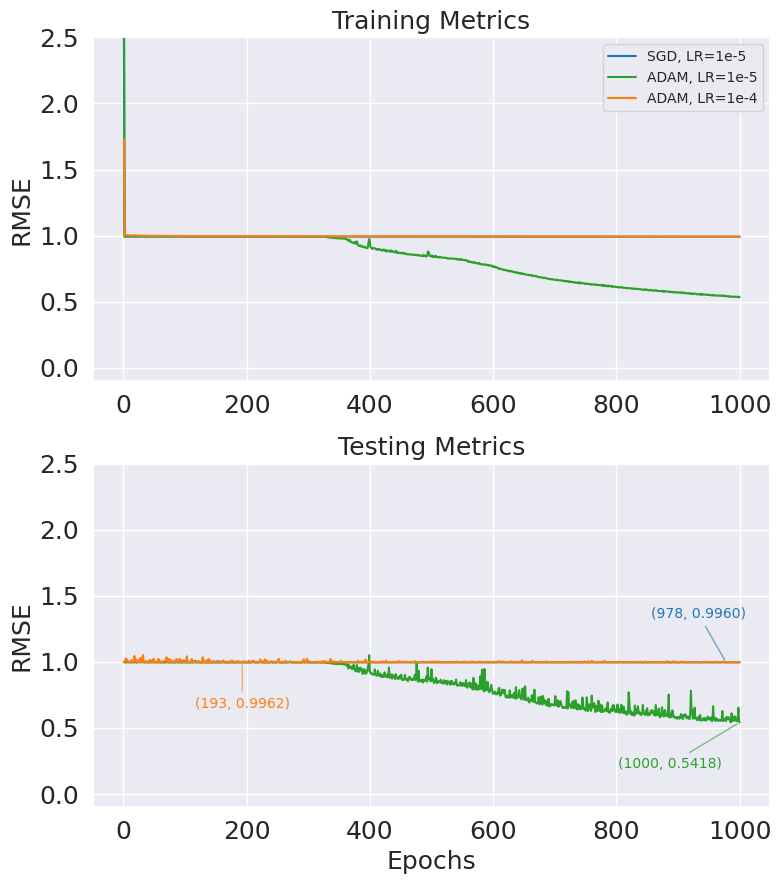

In [380]:
e_sgd_lr_1e_neg_5 = "../../results/run_results/blstm-NLP_preembedded/sgd.lr1e-5.blstm-NLP_preembedded-DMS_OLD-expression-2024-11-13_12-00/blstm-NLP_preembedded-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
e_adam_lr_1e_neg_5 = "../../results/run_results/blstm-NLP_preembedded/adam.lr1e-5.blstm-NLP_preembedded-DMS_OLD-expression-2024-11-15_23-17/blstm-NLP_preembedded-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
e_adam_lr_1e_neg_4 = "../../results/run_results/blstm-NLP_preembedded/adam.lr1e-4.blstm-NLP_preembedded-DMS_OLD-expression-2024-11-23_20-54/blstm-NLP_preembedded-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
comparison_file = "../../results/plots/model_comparisons/finetuning/blstm-nlp_preembedded.expression"
plot_comparative_lr_log_file(e_sgd_lr_1e_neg_5,e_adam_lr_1e_neg_5, e_adam_lr_1e_neg_4, f"{comparison_file}.model_comp.pdf")

---
### GCN ESM-AA Preembedded

Best test RMSE at epoch x:
SGD, LR=1e-5: epoch 988, rmse 1.3791
ADAM, LR=1e-5: epoch 994, rmse 1.2941
ADAM, LR=1e-4: epoch 988, rmse 1.0580


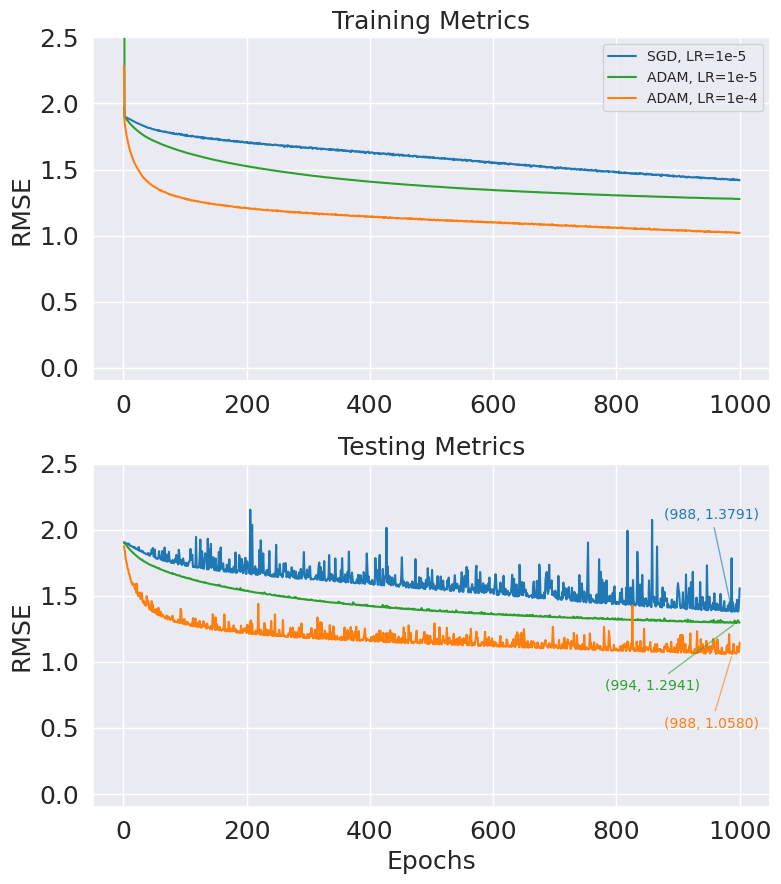

In [381]:
def plot_comparative_lr_log_file(metrics_csv_1, metrics_csv_2, metrics_csv_3, metrics_img):
    df1 = pd.read_csv(metrics_csv_1)
    df2 = pd.read_csv(metrics_csv_2)
    df3 = pd.read_csv(metrics_csv_3)

    sns.set_theme(style="darkgrid")
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 9))  # 2 rows, 1 column
    fontsize = 18

    # Plot 1: Training Metrics (binding, expression)
    ax1.plot(df1['Epoch'], df1['Train RMSE'], label='SGD, LR=1e-5', color='tab:blue', linestyle='-', linewidth=1.5)
    ax1.plot(df2['Epoch'], df2['Train RMSE'], label='ADAM, LR=1e-5', color='tab:green', linestyle='-', linewidth=1.5)
    ax1.plot(df3['Epoch'], df3['Train RMSE'], label='ADAM, LR=1e-4', color='tab:orange', linestyle='-', linewidth=1.5)

    ax1.tick_params(axis='x', labelsize=fontsize)    
    ax1.set_xlim(-50, 1050)
    ax1.set_ylabel('RMSE', fontsize=fontsize)
    ax1.tick_params(axis='y', labelsize=fontsize)
    ax1.set_ylim(-0.1, 2.5)
    ax1.legend(loc='upper right', fontsize=fontsize-8)
    ax1.set_title('Training Metrics', fontsize=fontsize)

    # Plot Best Test Loss
    best_df1_rmse = find_best_epoch(metrics_csv_1, 'Test RMSE')
    best_df2_rmse = find_best_epoch(metrics_csv_2, 'Test RMSE')
    best_df3_rmse = find_best_epoch(metrics_csv_3, 'Test RMSE')
    
    print("Best test RMSE at epoch x:")
    print(f"SGD, LR=1e-5: epoch {best_df1_rmse[0]}, rmse {best_df1_rmse[1]:.4f}")
    print(f"ADAM, LR=1e-5: epoch {best_df2_rmse[0]}, rmse {best_df2_rmse[1]:.4f}")
    print(f"ADAM, LR=1e-4: epoch {best_df3_rmse[0]}, rmse {best_df3_rmse[1]:.4f}")

    ax2.annotate(
        f'({best_df1_rmse[0]}, {best_df1_rmse[1]:.4f})', best_df1_rmse, 
        textcoords="offset points", xytext=(-15,75), ha='center', va='top', color='tab:blue', fontsize=fontsize-8,
        arrowprops=dict(arrowstyle="-", color='tab:blue', lw=1, alpha=0.6)
    )
    ax2.annotate(
        f'({best_df2_rmse[0]}, {best_df2_rmse[1]:.4f})', best_df2_rmse, 
        textcoords="offset points", xytext=(-60,-40), ha='center', va='top', color='tab:green', fontsize=fontsize-8,
        arrowprops=dict(arrowstyle="-", color='tab:green', lw=1, alpha=0.6)
    )
    ax2.annotate(
        f'({best_df3_rmse[0]}, {best_df3_rmse[1]:.4f})', best_df3_rmse, 
        textcoords="offset points", xytext=(-15,-45), ha='center', va='top', color='tab:orange', fontsize=fontsize-8,
        arrowprops=dict(arrowstyle="-", color='tab:orange', lw=1, alpha=0.6)
    )

    # Plot 2: Testing Metrics (binding, expression)
    ax2.plot(df1['Epoch'], df1['Test RMSE'], label='SGD, LR=1e-5', color='tab:blue', linestyle='-', linewidth=1.5)
    ax2.plot(df2['Epoch'], df2['Test RMSE'], label='ADAM, LR=1e-5', color='tab:green', linestyle='-', linewidth=1.5)
    ax2.plot(df3['Epoch'], df3['Test RMSE'], label='ADAM, LR=1e-4', color='tab:orange', linestyle='-', linewidth=1.5)

    ax2.set_xlabel('Epochs', fontsize=fontsize)
    ax2.tick_params(axis='x', labelsize=fontsize)
    ax2.set_xlim(-50, 1050)
    ax2.set_ylabel('RMSE', fontsize=fontsize)
    ax2.tick_params(axis='y', labelsize=fontsize)
    ax2.set_ylim(-0.1, 2.5)
    ax2.set_title('Testing Metrics', fontsize=fontsize)

    plt.tight_layout()
    plt.savefig(metrics_img, format='pdf')
    plt.savefig(metrics_img.replace('.pdf', '.png'), format='png')

b_sgd_lr_1e_neg_5 = "../../results/run_results/gcn-ESM_AA_preembedded/sgd.lr1e-5.gcn-ESM_AA_preembedded-DMS_OLD-binding-2024-11-16_20-26/gcn-ESM_AA_preembedded-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
b_adam_lr_1e_neg_5 = "../../results/run_results/gcn-ESM_AA_preembedded/adam.lr1e-5.gcn-ESM_AA_preembedded-DMS_OLD-binding-2024-11-21_17-06/gcn-ESM_AA_preembedded-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
b_adam_lr_1e_neg_4 = "../../results/run_results/gcn-ESM_AA_preembedded/adam.lr1e-4.gcn-ESM_AA_preembedded-DMS_OLD-binding-2024-11-21_17-07/gcn-ESM_AA_preembedded-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
comparison_file = "../../results/plots/model_comparisons/finetuning/gcn-esm_aa_preembedded.binding"
plot_comparative_lr_log_file(b_sgd_lr_1e_neg_5,b_adam_lr_1e_neg_5, b_adam_lr_1e_neg_4, f"{comparison_file}.model_comp.pdf")

Best test RMSE at epoch x:
SGD, LR=1e-5: epoch 997, rmse 0.8043
ADAM, LR=1e-5: epoch 992, rmse 0.6819
ADAM, LR=1e-4: epoch 998, rmse 0.5431


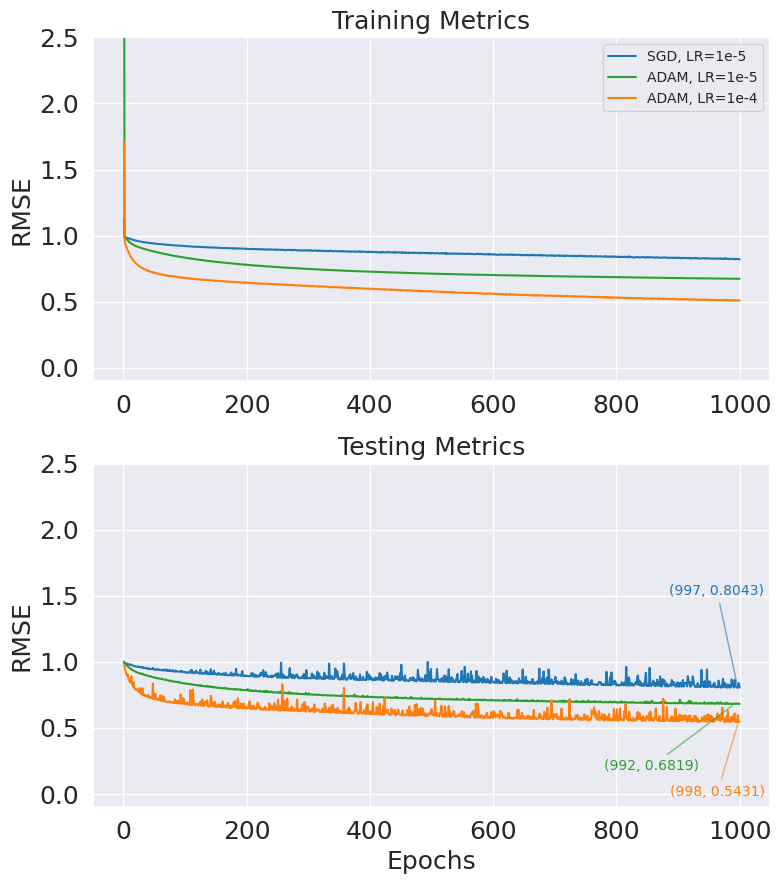

In [382]:
e_sgd_lr_1e_neg_5 = "../../results/run_results/gcn-ESM_AA_preembedded/sgd.lr1e-5.gcn-ESM_AA_preembedded-DMS_OLD-expression-2024-11-16_20-27/gcn-ESM_AA_preembedded-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
e_adam_lr_1e_neg_5 = "../../results/run_results/gcn-ESM_AA_preembedded/adam.lr1e-5.gcn-ESM_AA_preembedded-DMS_OLD-expression-2024-11-16_20-10/gcn-ESM_AA_preembedded-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
e_adam_lr_1e_neg_4 = "../../results/run_results/gcn-ESM_AA_preembedded/adam.lr1e-4.gcn-ESM_AA_preembedded-DMS_OLD-expression-2024-11-21_17-08/gcn-ESM_AA_preembedded-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
comparison_file = "../../results/plots/model_comparisons/finetuning/gcn-esm_aa_preembedded.expression"
plot_comparative_lr_log_file(e_sgd_lr_1e_neg_5,e_adam_lr_1e_neg_5, e_adam_lr_1e_neg_4, f"{comparison_file}.model_comp.pdf")

---
## Model Comparisons - Updating Embedding Models
### ADAM, LR = 1e-4
Binding

Best test RMSE at epoch x:
BERT-BLSTM Init. w/ BERT MLM-ESM INIT: epoch 620, rmse 1.0038
ESM-FCN: epoch 90, rmse 0.5313
ESM-GCN: epoch 58, rmse 0.5426
ESM-BLSTM: epoch 49, rmse 0.5612
ESM-BLSTM Init. w/ BERT MLM-ESM INIT: epoch 58, rmse 0.5883


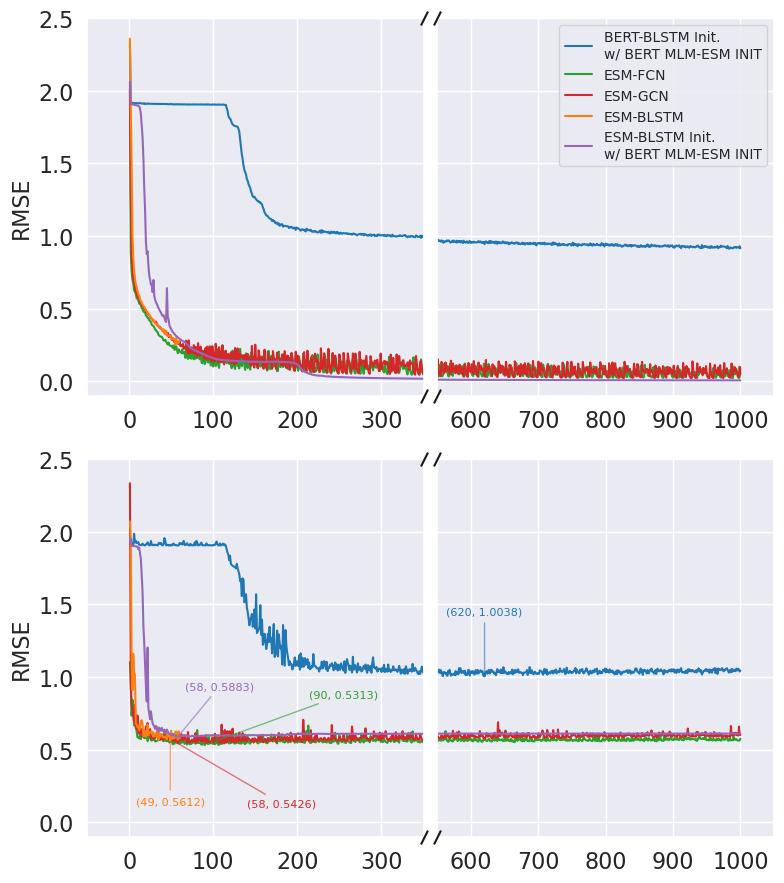

In [383]:
def plot_comparative_log_file(metrics_csv_1, metrics_csv_2, metrics_csv_3, metrics_csv_4, metrics_csv_5, metrics_img):
    df1 = pd.read_csv(metrics_csv_1)
    df2 = pd.read_csv(metrics_csv_2)
    df3 = pd.read_csv(metrics_csv_3)
    df4 = pd.read_csv(metrics_csv_4)
    df5 = pd.read_csv(metrics_csv_5)

    sns.set_theme(style="darkgrid")
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(8, 9), sharey=True)
    fig.subplots_adjust(wspace=0.05)
    fontsize = 16

    # Training Metrics
    ax1.plot(df1['Epoch'][:500], df1['Train BLSTM RMSE'][:500], label='BERT-BLSTM Init.\nw/ BERT MLM-ESM INIT', color='tab:blue', linestyle='-', linewidth=1.5)
    ax1.plot(df2['Epoch'][:500], df2['Train RMSE'][:500], label='ESM-FCN', color='tab:green', linestyle='-', linewidth=1.5)
    ax1.plot(df3['Epoch'][:500], df3['Train RMSE'][:500], label='ESM-GCN', color='tab:red', linestyle='-', linewidth=1.5)
    ax1.plot(df4['Epoch'][:500], df4['Train RMSE'][:500], label='ESM-BLSTM', color='tab:orange', linestyle='-', linewidth=1.5)
    ax1.plot(df5['Epoch'][:500], df5['Train RMSE'][:500], label='ESM-BLSTM Init.\nw/ BERT MLM-ESM INIT', color='tab:purple', linestyle='-', linewidth=1.5)

    ax2.plot(df1['Epoch'][500:], df1['Train BLSTM RMSE'][500:], label='BERT-BLSTM Init.\nw/ BERT MLM-ESM INIT', color='tab:blue', linestyle='-', linewidth=1.5)
    ax2.plot(df2['Epoch'][500:], df2['Train RMSE'][500:], label='ESM-FCN', color='tab:green', linestyle='-', linewidth=1.5)
    ax2.plot(df3['Epoch'][500:], df3['Train RMSE'][500:], label='ESM-GCN', color='tab:red', linestyle='-', linewidth=1.5)
    ax2.plot(df4['Epoch'][500:], df4['Train RMSE'][500:], label='ESM-BLSTM', color='tab:orange', linestyle='-', linewidth=1.5)
    ax2.plot(df5['Epoch'][500:], df5['Train RMSE'][500:], label='ESM-BLSTM Init.\nw/ BERT MLM-ESM INIT', color='tab:purple', linestyle='-', linewidth=1.5)

    # Testing Metrics
    ax3.plot(df1['Epoch'][:500], df1['Test BLSTM RMSE'][:500], label='BERT-BLSTM Init.\nw/ BERT MLM-ESM INIT', color='tab:blue', linestyle='-', linewidth=1.5)
    ax3.plot(df2['Epoch'][:500], df2['Test RMSE'][:500], label='ESM-FCN', color='tab:green', linestyle='-', linewidth=1.5)
    ax3.plot(df3['Epoch'][:500], df3['Test RMSE'][:500], label='ESM-GCN', color='tab:red', linestyle='-', linewidth=1.5)
    ax3.plot(df4['Epoch'][:500], df4['Test RMSE'][:500], label='ESM-BLSTM', color='tab:orange', linestyle='-', linewidth=1.5)
    ax3.plot(df5['Epoch'][:500], df5['Test RMSE'][:500], label='ESM-BLSTM Init.\nw/ BERT MLM-ESM INIT', color='tab:purple', linestyle='-', linewidth=1.5)

    ax4.plot(df1['Epoch'][500:], df1['Test BLSTM RMSE'][500:], label='BERT-BLSTM Init.\nw/ BERT MLM-ESM INIT', color='tab:blue', linestyle='-', linewidth=1.5)
    ax4.plot(df2['Epoch'][500:], df2['Test RMSE'][500:], label='ESM-FCN', color='tab:green', linestyle='-', linewidth=1.5)
    ax4.plot(df3['Epoch'][500:], df3['Test RMSE'][500:], label='ESM-GCN', color='tab:red', linestyle='-', linewidth=1.5)
    ax4.plot(df4['Epoch'][500:], df4['Test RMSE'][500:], label='ESM-BLSTM', color='tab:orange', linestyle='-', linewidth=1.5)
    ax4.plot(df5['Epoch'][500:], df5['Test RMSE'][500:], label='ESM-BLSTM Init.\nw/ BERT MLM-ESM INIT', color='tab:purple', linestyle='-', linewidth=1.5)

    # Plot Best Test Loss
    best_df1_rmse = find_best_epoch(metrics_csv_1, 'Test BLSTM RMSE')
    best_df2_rmse = find_best_epoch(metrics_csv_2, 'Test RMSE')
    best_df3_rmse = find_best_epoch(metrics_csv_3, 'Test RMSE')
    best_df4_rmse = find_best_epoch(metrics_csv_4, 'Test RMSE')
    best_df5_rmse = find_best_epoch(metrics_csv_5, 'Test RMSE')
    
    print("Best test RMSE at epoch x:")
    print(f"BERT-BLSTM Init. w/ BERT MLM-ESM INIT: epoch {best_df1_rmse[0]}, rmse {best_df1_rmse[1]:.4f}")
    print(f"ESM-FCN: epoch {best_df2_rmse[0]}, rmse {best_df2_rmse[1]:.4f}")
    print(f"ESM-GCN: epoch {best_df3_rmse[0]}, rmse {best_df3_rmse[1]:.4f}")
    print(f"ESM-BLSTM: epoch {best_df4_rmse[0]}, rmse {best_df4_rmse[1]:.4f}")
    print(f"ESM-BLSTM Init. w/ BERT MLM-ESM INIT: epoch {best_df5_rmse[0]}, rmse {best_df5_rmse[1]:.4f}")

    ax4.annotate(
        f'({best_df1_rmse[0]}, {best_df1_rmse[1]:.4f})', best_df1_rmse, 
        textcoords="offset points", xytext=(0,50), ha='center', va='top', color='tab:blue', fontsize=fontsize-8,
        arrowprops=dict(arrowstyle="-", color='tab:blue', lw=1, alpha=0.6)
    )
    ax3.annotate(
        f'({best_df2_rmse[0]}, {best_df2_rmse[1]:.4f})', best_df2_rmse, 
        textcoords="offset points", xytext=(100,40), ha='center', va='top', color='tab:green', fontsize=fontsize-8,
        arrowprops=dict(arrowstyle="-", color='tab:green', lw=1, alpha=0.6)
    )
    ax3.annotate(
        f'({best_df3_rmse[0]}, {best_df3_rmse[1]:.4f})', best_df3_rmse, 
        textcoords="offset points", xytext=(75,-40), ha='center', va='top', color='tab:red', fontsize=fontsize-8,
        arrowprops=dict(arrowstyle="-", color='tab:red', lw=1, alpha=0.6)
    )
    ax3.annotate(
        f'({best_df4_rmse[0]}, {best_df4_rmse[1]:.4f})', best_df4_rmse, 
        textcoords="offset points", xytext=(0,-40), ha='center', va='top', color='tab:orange', fontsize=fontsize-8,
        arrowprops=dict(arrowstyle="-", color='tab:orange', lw=1, alpha=0.6)
    )
    ax3.annotate(
        f'({best_df5_rmse[0]}, {best_df5_rmse[1]:.4f})', best_df5_rmse, 
        textcoords="offset points", xytext=(30,40), ha='center', va='top', color='tab:purple', fontsize=fontsize-8,
        arrowprops=dict(arrowstyle="-", color='tab:purple', lw=1, alpha=0.6)
    )

    # Customize axes
    for ax in [ax1, ax2, ax3, ax4]:
        ax.set_ylim(-0.1, 2.5)
        ax.tick_params(axis='both', labelsize=fontsize)

    ax1.set_xlim(-50, 350)
    ax2.set_xlim(550, 1050)
    ax3.set_xlim(-50, 350)
    ax4.set_xlim(550, 1050)

    ax1.set_ylabel('RMSE', fontsize=fontsize)
    ax3.set_ylabel('RMSE', fontsize=fontsize)

    # Add legend to the first subplot
    ax2.legend(loc='upper right', fontsize=fontsize-6)

    # Add the slanted lines for axis split
    d = .5
    kwargs = dict(marker=[(-d, -1), (d, 1)], markersize=10,
                linestyle="none", color='k', mec='k', mew=1.5, clip_on=False, zorder=5)
    ax1.plot([1, 1], [0, 1], transform=ax1.transAxes, **kwargs)
    ax2.plot([0, 0], [0, 1], transform=ax2.transAxes, **kwargs)
    ax3.plot([1, 1], [0, 1], transform=ax3.transAxes, **kwargs)
    ax4.plot([0, 0], [0, 1], transform=ax4.transAxes, **kwargs)

    plt.tight_layout(w_pad=0)
    plt.savefig(metrics_img, format='pdf')
    plt.savefig(metrics_img.replace('.pdf', '.png'), format='png')

bert_blstm = "../../results/run_results/bert_blstm/adam.lr1e-4.bert_blstm-DMS_OLD-binding-2024-11-23_21-43/bert_blstm-DMS_OLD-train_82178_test_20545_metrics.csv"
esm_fcn = "../../results/run_results/esm_fcn/adam.lr1e-4.esm_fcn-DMS_OLD-binding-2024-11-24_05-48/esm_fcn-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
esm_gcn = "../../results/run_results/esm_gcn/adam.lr1e-4.esm_gcn-DMS_OLD-binding-2024-11-25_15-54/esm_gcn-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
esm_blstm = "../../results/run_results/esm_blstm/adam.lr1e-4.esm_blstm-DMS_OLD-binding-2024-11-26_08-29/esm_blstm-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
esm_blstm_bert_mlm_esm_init = "../../results/run_results/esm_blstm-bert_mlm_esm_init/adam.lr1e-4.esm_blstm-bert_mlm_esm_init-DMS_OLD-binding-2024-11-21_10-38/esm_blstm-bert_mlm_esm_init-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
comparison_file = "../../results/plots/model_comparisons/finetuning/adam.lr1e-4.binding"

plot_comparative_log_file(bert_blstm, esm_fcn, esm_gcn, esm_blstm, esm_blstm_bert_mlm_esm_init, f"{comparison_file}.model_comp_split.pdf")

Best test RMSE at epoch x:
BERT-BLSTM Init. w/ BERT MLM-ESM INIT: epoch 620, rmse 1.0038
ESM-FCN: epoch 90, rmse 0.5313
ESM-GCN: epoch 58, rmse 0.5426
ESM-BLSTM: epoch 49, rmse 0.5612
ESM-BLSTM Init. w/ BERT MLM-ESM INIT: epoch 58, rmse 0.5883


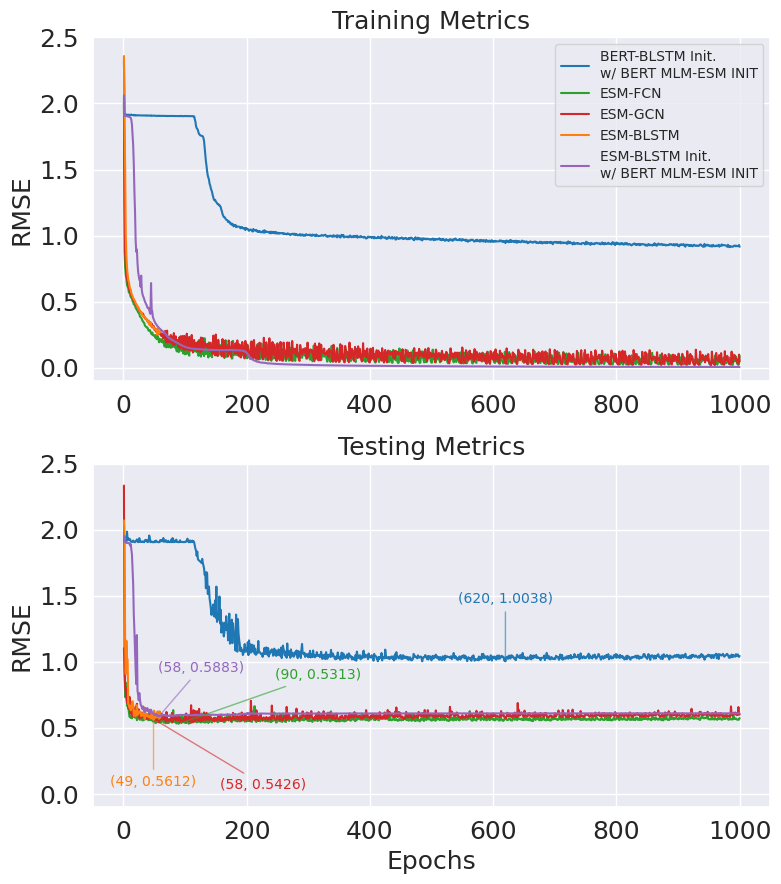

In [384]:
def plot_comparative_log_file(metrics_csv_1, metrics_csv_2, metrics_csv_3, metrics_csv_4, metrics_csv_5, metrics_img):
    df1 = pd.read_csv(metrics_csv_1)
    df2 = pd.read_csv(metrics_csv_2)
    df3 = pd.read_csv(metrics_csv_3)
    df4 = pd.read_csv(metrics_csv_4)
    df5 = pd.read_csv(metrics_csv_5)

    sns.set_theme(style="darkgrid")
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 9))  # 2 rows, 1 column
    fontsize = 18

    # Plot 1: Training Metrics (binding, expression)
    ax1.plot(df1['Epoch'], df1['Train BLSTM RMSE'], label='BERT-BLSTM Init.\nw/ BERT MLM-ESM INIT', color='tab:blue', linestyle='-', linewidth=1.5)
    ax1.plot(df2['Epoch'], df2['Train RMSE'], label='ESM-FCN', color='tab:green', linestyle='-', linewidth=1.5)
    ax1.plot(df3['Epoch'], df3['Train RMSE'], label='ESM-GCN', color='tab:red', linestyle='-', linewidth=1.5)
    ax1.plot(df4['Epoch'], df4['Train RMSE'], label='ESM-BLSTM', color='tab:orange', linestyle='-', linewidth=1.5)
    ax1.plot(df5['Epoch'], df5['Train RMSE'], label='ESM-BLSTM Init.\nw/ BERT MLM-ESM INIT', color='tab:purple', linestyle='-', linewidth=1.5)

    ax1.tick_params(axis='x', labelsize=fontsize)    
    ax1.set_xlim(-50, 1050)
    ax1.set_ylabel('RMSE', fontsize=fontsize)
    ax1.tick_params(axis='y', labelsize=fontsize)
    ax1.set_ylim(-0.1, 2.5)
    ax1.legend(loc='upper right', fontsize=fontsize-8)
    ax1.set_title('Training Metrics', fontsize=fontsize)

    # Plot Best Test Loss
    best_df1_rmse = find_best_epoch(metrics_csv_1, 'Test BLSTM RMSE')
    best_df2_rmse = find_best_epoch(metrics_csv_2, 'Test RMSE')
    best_df3_rmse = find_best_epoch(metrics_csv_3, 'Test RMSE')
    best_df4_rmse = find_best_epoch(metrics_csv_4, 'Test RMSE')
    best_df5_rmse = find_best_epoch(metrics_csv_5, 'Test RMSE')
    
    print("Best test RMSE at epoch x:")
    print(f"BERT-BLSTM Init. w/ BERT MLM-ESM INIT: epoch {best_df1_rmse[0]}, rmse {best_df1_rmse[1]:.4f}")
    print(f"ESM-FCN: epoch {best_df2_rmse[0]}, rmse {best_df2_rmse[1]:.4f}")
    print(f"ESM-GCN: epoch {best_df3_rmse[0]}, rmse {best_df3_rmse[1]:.4f}")
    print(f"ESM-BLSTM: epoch {best_df4_rmse[0]}, rmse {best_df4_rmse[1]:.4f}")
    print(f"ESM-BLSTM Init. w/ BERT MLM-ESM INIT: epoch {best_df5_rmse[0]}, rmse {best_df5_rmse[1]:.4f}")

    ax2.annotate(
        f'({best_df1_rmse[0]}, {best_df1_rmse[1]:.4f})', best_df1_rmse, 
        textcoords="offset points", xytext=(0,50), ha='center', va='top', color='tab:blue', fontsize=fontsize-8,
        arrowprops=dict(arrowstyle="-", color='tab:blue', lw=1, alpha=0.6)
    )
    ax2.annotate(
        f'({best_df2_rmse[0]}, {best_df2_rmse[1]:.4f})', best_df2_rmse, 
        textcoords="offset points", xytext=(100,40), ha='center', va='top', color='tab:green', fontsize=fontsize-8,
        arrowprops=dict(arrowstyle="-", color='tab:green', lw=1, alpha=0.6)
    )
    ax2.annotate(
        f'({best_df3_rmse[0]}, {best_df3_rmse[1]:.4f})', best_df3_rmse, 
        textcoords="offset points", xytext=(75,-40), ha='center', va='top', color='tab:red', fontsize=fontsize-8,
        arrowprops=dict(arrowstyle="-", color='tab:red', lw=1, alpha=0.6)
    )
    ax2.annotate(
        f'({best_df4_rmse[0]}, {best_df4_rmse[1]:.4f})', best_df4_rmse, 
        textcoords="offset points", xytext=(0,-40), ha='center', va='top', color='tab:orange', fontsize=fontsize-8,
        arrowprops=dict(arrowstyle="-", color='tab:orange', lw=1, alpha=0.6)
    )
    ax2.annotate(
        f'({best_df5_rmse[0]}, {best_df5_rmse[1]:.4f})', best_df5_rmse, 
        textcoords="offset points", xytext=(30,40), ha='center', va='top', color='tab:purple', fontsize=fontsize-8,
        arrowprops=dict(arrowstyle="-", color='tab:purple', lw=1, alpha=0.6)
    )

    # Plot 2: Testing Metrics (binding, expression)
    ax2.plot(df1['Epoch'], df1['Test BLSTM RMSE'], label='BERT-BLSTM Init.\nw/ BERT MLM-ESM INIT', color='tab:blue', linestyle='-', linewidth=1.5)
    ax2.plot(df2['Epoch'], df2['Test RMSE'], label='ESM-FCN', color='tab:green', linestyle='-', linewidth=1.5)
    ax2.plot(df3['Epoch'], df3['Test RMSE'], label='ESM-GCN', color='tab:red', linestyle='-', linewidth=1.5)
    ax2.plot(df4['Epoch'], df4['Test RMSE'], label='ESM-BLSTM', color='tab:orange', linestyle='-', linewidth=1.5)
    ax2.plot(df5['Epoch'], df5['Test RMSE'], label='ESM-BLSTM Init.\nw/ BERT MLM-ESM INIT', color='tab:purple', linestyle='-', linewidth=1.5)

    ax2.set_xlabel('Epochs', fontsize=fontsize)
    ax2.tick_params(axis='x', labelsize=fontsize)
    ax2.set_xlim(-50, 1050)
    ax2.set_ylabel('RMSE', fontsize=fontsize)
    ax2.tick_params(axis='y', labelsize=fontsize)
    ax2.set_ylim(-0.1, 2.5)
    ax2.set_title('Testing Metrics', fontsize=fontsize)

    plt.tight_layout()
    plt.savefig(metrics_img, format='pdf')
    plt.savefig(metrics_img.replace('.pdf', '.png'), format='png')

bert_blstm = "../../results/run_results/bert_blstm/adam.lr1e-4.bert_blstm-DMS_OLD-binding-2024-11-23_21-43/bert_blstm-DMS_OLD-train_82178_test_20545_metrics.csv"
esm_fcn = "../../results/run_results/esm_fcn/adam.lr1e-4.esm_fcn-DMS_OLD-binding-2024-11-24_05-48/esm_fcn-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
esm_gcn = "../../results/run_results/esm_gcn/adam.lr1e-4.esm_gcn-DMS_OLD-binding-2024-11-25_15-54/esm_gcn-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
esm_blstm = "../../results/run_results/esm_blstm/adam.lr1e-4.esm_blstm-DMS_OLD-binding-2024-11-26_08-29/esm_blstm-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
esm_blstm_bert_mlm_esm_init = "../../results/run_results/esm_blstm-bert_mlm_esm_init/adam.lr1e-4.esm_blstm-bert_mlm_esm_init-DMS_OLD-binding-2024-11-21_10-38/esm_blstm-bert_mlm_esm_init-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
comparison_file = "../../results/plots/model_comparisons/finetuning/adam.lr1e-4.binding"

plot_comparative_log_file(bert_blstm, esm_fcn, esm_gcn, esm_blstm, esm_blstm_bert_mlm_esm_init, f"{comparison_file}.model_comp.pdf")

Expression

Best test RMSE at epoch x:
BERT-BLSTM Init. w/ BERT MLM-ESM INIT: epoch 937, rmse 0.5572
ESM-FCN: epoch 159, rmse 0.3163
ESM-GCN: epoch 171, rmse 0.3270
ESM-BLSTM: epoch 56, rmse 0.3365
ESM-BLSTM Init. w/ BERT MLM-ESM INIT: epoch 61, rmse 0.3789


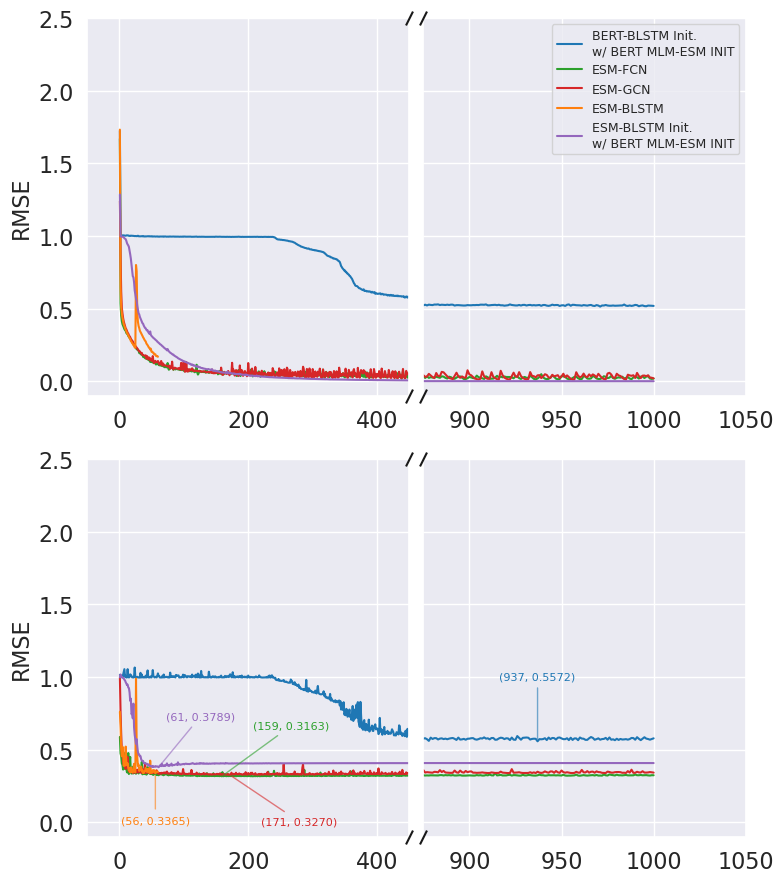

In [385]:
def plot_comparative_log_file(metrics_csv_1, metrics_csv_2, metrics_csv_3, metrics_csv_4, metrics_csv_5, metrics_img):
    df1 = pd.read_csv(metrics_csv_1)
    df2 = pd.read_csv(metrics_csv_2)
    df3 = pd.read_csv(metrics_csv_3)
    df4 = pd.read_csv(metrics_csv_4)
    df5 = pd.read_csv(metrics_csv_5)

    sns.set_theme(style="darkgrid")
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(8, 9), sharey=True)
    fig.subplots_adjust(wspace=0.05)
    fontsize = 16

    # Training Metrics
    ax1.plot(df1['Epoch'][:500], df1['Train BLSTM RMSE'][:500], label='BERT-BLSTM Init.\nw/ BERT MLM-ESM INIT', color='tab:blue', linestyle='-', linewidth=1.5)
    ax1.plot(df2['Epoch'][:500], df2['Train RMSE'][:500], label='ESM-FCN', color='tab:green', linestyle='-', linewidth=1.5)
    ax1.plot(df3['Epoch'][:500], df3['Train RMSE'][:500], label='ESM-GCN', color='tab:red', linestyle='-', linewidth=1.5)
    ax1.plot(df4['Epoch'][:500], df4['Train RMSE'][:500], label='ESM-BLSTM', color='tab:orange', linestyle='-', linewidth=1.5)
    ax1.plot(df5['Epoch'][:500], df5['Train RMSE'][:500], label='ESM-BLSTM Init.\nw/ BERT MLM-ESM INIT', color='tab:purple', linestyle='-', linewidth=1.5)

    ax2.plot(df1['Epoch'][500:], df1['Train BLSTM RMSE'][500:], label='BERT-BLSTM Init.\nw/ BERT MLM-ESM INIT', color='tab:blue', linestyle='-', linewidth=1.5)
    ax2.plot(df2['Epoch'][500:], df2['Train RMSE'][500:], label='ESM-FCN', color='tab:green', linestyle='-', linewidth=1.5)
    ax2.plot(df3['Epoch'][500:], df3['Train RMSE'][500:], label='ESM-GCN', color='tab:red', linestyle='-', linewidth=1.5)
    ax2.plot(df4['Epoch'][500:], df4['Train RMSE'][500:], label='ESM-BLSTM', color='tab:orange', linestyle='-', linewidth=1.5)
    ax2.plot(df5['Epoch'][500:], df5['Train RMSE'][500:], label='ESM-BLSTM Init.\nw/ BERT MLM-ESM INIT', color='tab:purple', linestyle='-', linewidth=1.5)

    # Testing Metrics
    ax3.plot(df1['Epoch'][:500], df1['Test BLSTM RMSE'][:500], label='BERT-BLSTM Init.\nw/ BERT MLM-ESM INIT', color='tab:blue', linestyle='-', linewidth=1.5)
    ax3.plot(df2['Epoch'][:500], df2['Test RMSE'][:500], label='ESM-FCN', color='tab:green', linestyle='-', linewidth=1.5)
    ax3.plot(df3['Epoch'][:500], df3['Test RMSE'][:500], label='ESM-GCN', color='tab:red', linestyle='-', linewidth=1.5)
    ax3.plot(df4['Epoch'][:500], df4['Test RMSE'][:500], label='ESM-BLSTM', color='tab:orange', linestyle='-', linewidth=1.5)
    ax3.plot(df5['Epoch'][:500], df5['Test RMSE'][:500], label='ESM-BLSTM Init.\nw/ BERT MLM-ESM INIT', color='tab:purple', linestyle='-', linewidth=1.5)

    ax4.plot(df1['Epoch'][500:], df1['Test BLSTM RMSE'][500:], label='BERT-BLSTM Init.\nw/ BERT MLM-ESM INIT', color='tab:blue', linestyle='-', linewidth=1.5)
    ax4.plot(df2['Epoch'][500:], df2['Test RMSE'][500:], label='ESM-FCN', color='tab:green', linestyle='-', linewidth=1.5)
    ax4.plot(df3['Epoch'][500:], df3['Test RMSE'][500:], label='ESM-GCN', color='tab:red', linestyle='-', linewidth=1.5)
    ax4.plot(df4['Epoch'][500:], df4['Test RMSE'][500:], label='ESM-BLSTM', color='tab:orange', linestyle='-', linewidth=1.5)
    ax4.plot(df5['Epoch'][500:], df5['Test RMSE'][500:], label='ESM-BLSTM Init.\nw/ BERT MLM-ESM INIT', color='tab:purple', linestyle='-', linewidth=1.5)

    # Plot Best Test Loss
    best_df1_rmse = find_best_epoch(metrics_csv_1, 'Test BLSTM RMSE')
    best_df2_rmse = find_best_epoch(metrics_csv_2, 'Test RMSE')
    best_df3_rmse = find_best_epoch(metrics_csv_3, 'Test RMSE')
    best_df4_rmse = find_best_epoch(metrics_csv_4, 'Test RMSE')
    best_df5_rmse = find_best_epoch(metrics_csv_5, 'Test RMSE')
    
    print("Best test RMSE at epoch x:")
    print(f"BERT-BLSTM Init. w/ BERT MLM-ESM INIT: epoch {best_df1_rmse[0]}, rmse {best_df1_rmse[1]:.4f}")
    print(f"ESM-FCN: epoch {best_df2_rmse[0]}, rmse {best_df2_rmse[1]:.4f}")
    print(f"ESM-GCN: epoch {best_df3_rmse[0]}, rmse {best_df3_rmse[1]:.4f}")
    print(f"ESM-BLSTM: epoch {best_df4_rmse[0]}, rmse {best_df4_rmse[1]:.4f}")
    print(f"ESM-BLSTM Init. w/ BERT MLM-ESM INIT: epoch {best_df5_rmse[0]}, rmse {best_df5_rmse[1]:.4f}")

    ax4.annotate(
        f'({best_df1_rmse[0]}, {best_df1_rmse[1]:.4f})', best_df1_rmse, 
        textcoords="offset points", xytext=(0,50), ha='center', va='top', color='tab:blue', fontsize=fontsize-8,
        arrowprops=dict(arrowstyle="-", color='tab:blue', lw=1, alpha=0.6)
    )
    ax3.annotate(
        f'({best_df2_rmse[0]}, {best_df2_rmse[1]:.4f})', best_df2_rmse, 
        textcoords="offset points", xytext=(50,40), ha='center', va='top', color='tab:green', fontsize=fontsize-8,
        arrowprops=dict(arrowstyle="-", color='tab:green', lw=1, alpha=0.6)
    )
    ax3.annotate(
        f'({best_df3_rmse[0]}, {best_df3_rmse[1]:.4f})', best_df3_rmse, 
        textcoords="offset points", xytext=(50,-30), ha='center', va='top', color='tab:red', fontsize=fontsize-8,
        arrowprops=dict(arrowstyle="-", color='tab:red', lw=1, alpha=0.6)
    )
    ax3.annotate(
        f'({best_df4_rmse[0]}, {best_df4_rmse[1]:.4f})', best_df4_rmse, 
        textcoords="offset points", xytext=(0,-30), ha='center', va='top', color='tab:orange', fontsize=fontsize-8,
        arrowprops=dict(arrowstyle="-", color='tab:orange', lw=1, alpha=0.6)
    )
    ax3.annotate(
        f'({best_df5_rmse[0]}, {best_df5_rmse[1]:.4f})', best_df5_rmse, 
        textcoords="offset points", xytext=(30,40), ha='center', va='top', color='tab:purple', fontsize=fontsize-8,
        arrowprops=dict(arrowstyle="-", color='tab:purple', lw=1, alpha=0.6)
    )

    # Customize axes
    for ax in [ax1, ax2, ax3, ax4]:
        ax.set_ylim(-0.1, 2.5)
        ax.tick_params(axis='both', labelsize=fontsize)

    ax1.set_xlim(-50, 450)
    ax2.set_xlim(875, 1050)
    ax3.set_xlim(-50, 450)
    ax4.set_xlim(875, 1050)

    ax1.set_ylabel('RMSE', fontsize=fontsize)
    ax3.set_ylabel('RMSE', fontsize=fontsize)

    # Add legend to the first subplot
    ax2.legend(loc='upper right', fontsize=fontsize-7)

    # Add the slanted lines for axis split
    d = .5
    kwargs = dict(marker=[(-d, -1), (d, 1)], markersize=10,
                linestyle="none", color='k', mec='k', mew=1.5, clip_on=False, zorder=5)
    ax1.plot([1, 1], [0, 1], transform=ax1.transAxes, **kwargs)
    ax2.plot([0, 0], [0, 1], transform=ax2.transAxes, **kwargs)
    ax3.plot([1, 1], [0, 1], transform=ax3.transAxes, **kwargs)
    ax4.plot([0, 0], [0, 1], transform=ax4.transAxes, **kwargs)

    plt.tight_layout(w_pad=0)
    plt.savefig(metrics_img, format='pdf')
    plt.savefig(metrics_img.replace('.pdf', '.png'), format='png')

bert_blstm = "../../results/run_results/bert_blstm/adam.lr1e-4.bert_blstm-DMS_OLD-expression-2024-11-23_21-41/bert_blstm-DMS_OLD-train_82178_test_20545_metrics.csv"
esm_fcn = "../../results/run_results/esm_fcn/adam.lr1e-4.esm_fcn-DMS_OLD-expression-2024-11-24_05-47/esm_fcn-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
esm_gcn = "../../results/run_results/esm_gcn/adam.lr1e-4.esm_gcn-DMS_OLD-expression-2024-11-25_15-55/esm_gcn-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
esm_blstm = "../../results/run_results/esm_blstm/adam.lr1e-4.esm_blstm-DMS_OLD-expression-2024-11-26_08-28/esm_blstm-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
esm_blstm_bert_mlm_esm_init = "../../results/run_results/esm_blstm-bert_mlm_esm_init/adam.lr1e-4.esm_blstm-bert_mlm_esm_init-DMS_OLD-expression-2024-11-21_10-38/esm_blstm-bert_mlm_esm_init-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
comparison_file = "../../results/plots/model_comparisons/finetuning/adam.lr1e-4.expression"

plot_comparative_log_file(bert_blstm, esm_fcn, esm_gcn, esm_blstm, esm_blstm_bert_mlm_esm_init, f"{comparison_file}.model_comp_split.pdf")

Best test RMSE at epoch x:
BERT-BLSTM Init. w/ BERT MLM-ESM INIT: epoch 937, rmse 0.5572
ESM-FCN: epoch 159, rmse 0.3163
ESM-GCN: epoch 171, rmse 0.3270
ESM-BLSTM: epoch 56, rmse 0.3365
ESM-BLSTM Init. w/ BERT MLM-ESM INIT: epoch 61, rmse 0.3789


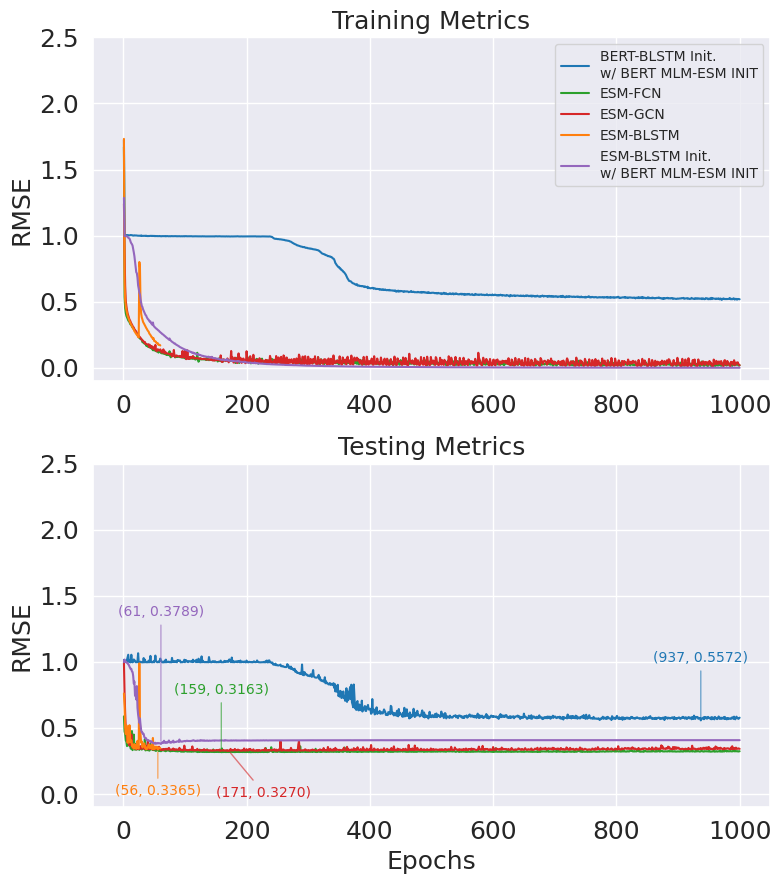

In [386]:
def plot_comparative_log_file(metrics_csv_1, metrics_csv_2, metrics_csv_3, metrics_csv_4, metrics_csv_5, metrics_img):
    df1 = pd.read_csv(metrics_csv_1)
    df2 = pd.read_csv(metrics_csv_2)
    df3 = pd.read_csv(metrics_csv_3)
    df4 = pd.read_csv(metrics_csv_4)
    df5 = pd.read_csv(metrics_csv_5)

    sns.set_theme(style="darkgrid")
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 9))  # 2 rows, 1 column
    fontsize = 18

    # Plot 1: Training Metrics (binding, expression)
    ax1.plot(df1['Epoch'], df1['Train BLSTM RMSE'], label='BERT-BLSTM Init.\nw/ BERT MLM-ESM INIT', color='tab:blue', linestyle='-', linewidth=1.5)
    ax1.plot(df2['Epoch'], df2['Train RMSE'], label='ESM-FCN', color='tab:green', linestyle='-', linewidth=1.5)
    ax1.plot(df3['Epoch'], df3['Train RMSE'], label='ESM-GCN', color='tab:red', linestyle='-', linewidth=1.5)
    ax1.plot(df4['Epoch'], df4['Train RMSE'], label='ESM-BLSTM', color='tab:orange', linestyle='-', linewidth=1.5)
    ax1.plot(df5['Epoch'], df5['Train RMSE'], label='ESM-BLSTM Init.\nw/ BERT MLM-ESM INIT', color='tab:purple', linestyle='-', linewidth=1.5)

    ax1.tick_params(axis='x', labelsize=fontsize)    
    ax1.set_xlim(-50, 1050)
    ax1.set_ylabel('RMSE', fontsize=fontsize)
    ax1.tick_params(axis='y', labelsize=fontsize)
    ax1.set_ylim(-0.1, 2.5)
    ax1.legend(loc='upper right', fontsize=fontsize-8)
    ax1.set_title('Training Metrics', fontsize=fontsize)

    # Plot Best Test Loss
    best_df1_rmse = find_best_epoch(metrics_csv_1, 'Test BLSTM RMSE')
    best_df2_rmse = find_best_epoch(metrics_csv_2, 'Test RMSE')
    best_df3_rmse = find_best_epoch(metrics_csv_3, 'Test RMSE')
    best_df4_rmse = find_best_epoch(metrics_csv_4, 'Test RMSE')
    best_df5_rmse = find_best_epoch(metrics_csv_5, 'Test RMSE')
    
    print("Best test RMSE at epoch x:")
    print(f"BERT-BLSTM Init. w/ BERT MLM-ESM INIT: epoch {best_df1_rmse[0]}, rmse {best_df1_rmse[1]:.4f}")
    print(f"ESM-FCN: epoch {best_df2_rmse[0]}, rmse {best_df2_rmse[1]:.4f}")
    print(f"ESM-GCN: epoch {best_df3_rmse[0]}, rmse {best_df3_rmse[1]:.4f}")
    print(f"ESM-BLSTM: epoch {best_df4_rmse[0]}, rmse {best_df4_rmse[1]:.4f}")
    print(f"ESM-BLSTM Init. w/ BERT MLM-ESM INIT: epoch {best_df5_rmse[0]}, rmse {best_df5_rmse[1]:.4f}")

    ax2.annotate(
        f'({best_df1_rmse[0]}, {best_df1_rmse[1]:.4f})', best_df1_rmse, 
        textcoords="offset points", xytext=(0,50), ha='center', va='top', color='tab:blue', fontsize=fontsize-8,
        arrowprops=dict(arrowstyle="-", color='tab:blue', lw=1, alpha=0.6)
    )
    ax2.annotate(
        f'({best_df2_rmse[0]}, {best_df2_rmse[1]:.4f})', best_df2_rmse, 
        textcoords="offset points", xytext=(0,50), ha='center', va='top', color='tab:green', fontsize=fontsize-8,
        arrowprops=dict(arrowstyle="-", color='tab:green', lw=1, alpha=0.6)
    )
    ax2.annotate(
        f'({best_df3_rmse[0]}, {best_df3_rmse[1]:.4f})', best_df3_rmse, 
        textcoords="offset points", xytext=(25,-25), ha='center', va='top', color='tab:red', fontsize=fontsize-8,
        arrowprops=dict(arrowstyle="-", color='tab:red', lw=1, alpha=0.6)
    )
    ax2.annotate(
        f'({best_df4_rmse[0]}, {best_df4_rmse[1]:.4f})', best_df4_rmse, 
        textcoords="offset points", xytext=(0,-25), ha='center', va='top', color='tab:orange', fontsize=fontsize-8,
        arrowprops=dict(arrowstyle="-", color='tab:orange', lw=1, alpha=0.6)
    )
    ax2.annotate(
        f'({best_df5_rmse[0]}, {best_df5_rmse[1]:.4f})', best_df5_rmse, 
        textcoords="offset points", xytext=(0,100), ha='center', va='top', color='tab:purple', fontsize=fontsize-8,
        arrowprops=dict(arrowstyle="-", color='tab:purple', lw=1, alpha=0.6)
    )

    # Plot 2: Testing Metrics (binding, expression)
    ax2.plot(df1['Epoch'], df1['Test BLSTM RMSE'], label='BERT-BLSTM Init.\nw/ BERT MLM-ESM INIT', color='tab:blue', linestyle='-', linewidth=1.5)
    ax2.plot(df2['Epoch'], df2['Test RMSE'], label='ESM-FCN', color='tab:green', linestyle='-', linewidth=1.5)
    ax2.plot(df3['Epoch'], df3['Test RMSE'], label='ESM-GCN', color='tab:red', linestyle='-', linewidth=1.5)
    ax2.plot(df4['Epoch'], df4['Test RMSE'], label='ESM-BLSTM', color='tab:orange', linestyle='-', linewidth=1.5)
    ax2.plot(df5['Epoch'], df5['Test RMSE'], label='ESM-BLSTM Init.\nw/ BERT MLM-ESM INIT', color='tab:purple', linestyle='-', linewidth=1.5)

    ax2.set_xlabel('Epochs', fontsize=fontsize)
    ax2.tick_params(axis='x', labelsize=fontsize)
    ax2.set_xlim(-50, 1050)
    ax2.set_ylabel('RMSE', fontsize=fontsize)
    ax2.tick_params(axis='y', labelsize=fontsize)
    ax2.set_ylim(-0.1, 2.5)
    ax2.set_title('Testing Metrics', fontsize=fontsize)

    plt.tight_layout()
    plt.savefig(metrics_img, format='pdf')
    plt.savefig(metrics_img.replace('.pdf', '.png'), format='png')

bert_blstm = "../../results/run_results/bert_blstm/adam.lr1e-4.bert_blstm-DMS_OLD-expression-2024-11-23_21-41/bert_blstm-DMS_OLD-train_82178_test_20545_metrics.csv"
esm_fcn = "../../results/run_results/esm_fcn/adam.lr1e-4.esm_fcn-DMS_OLD-expression-2024-11-24_05-47/esm_fcn-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
esm_gcn = "../../results/run_results/esm_gcn/adam.lr1e-4.esm_gcn-DMS_OLD-expression-2024-11-25_15-55/esm_gcn-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
esm_blstm = "../../results/run_results/esm_blstm/adam.lr1e-4.esm_blstm-DMS_OLD-expression-2024-11-26_08-28/esm_blstm-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
esm_blstm_bert_mlm_esm_init = "../../results/run_results/esm_blstm-bert_mlm_esm_init/adam.lr1e-4.esm_blstm-bert_mlm_esm_init-DMS_OLD-expression-2024-11-21_10-38/esm_blstm-bert_mlm_esm_init-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
comparison_file = "../../results/plots/model_comparisons/finetuning/adam.lr1e-4.expression"

plot_comparative_log_file(bert_blstm, esm_fcn, esm_gcn, esm_blstm, esm_blstm_bert_mlm_esm_init, f"{comparison_file}.model_comp.pdf")

---
## Model Comparisons - Frozen Embedding (Preembedded) Models
### ADAM, LR = 1e-5
Binding

Best test RMSE at epoch x:
FCN ESM-CLS Preembedded: epoch 929, rmse 1.2137
BLSTM ESM-AA Preembedded: epoch 864, rmse 0.5988
BLSTM NLP Preembedded Init. w/ BERT MLM-ESM INIT: epoch 983, rmse 0.8833
GCN ESM-AA Preembedded: epoch 994, rmse 1.2941


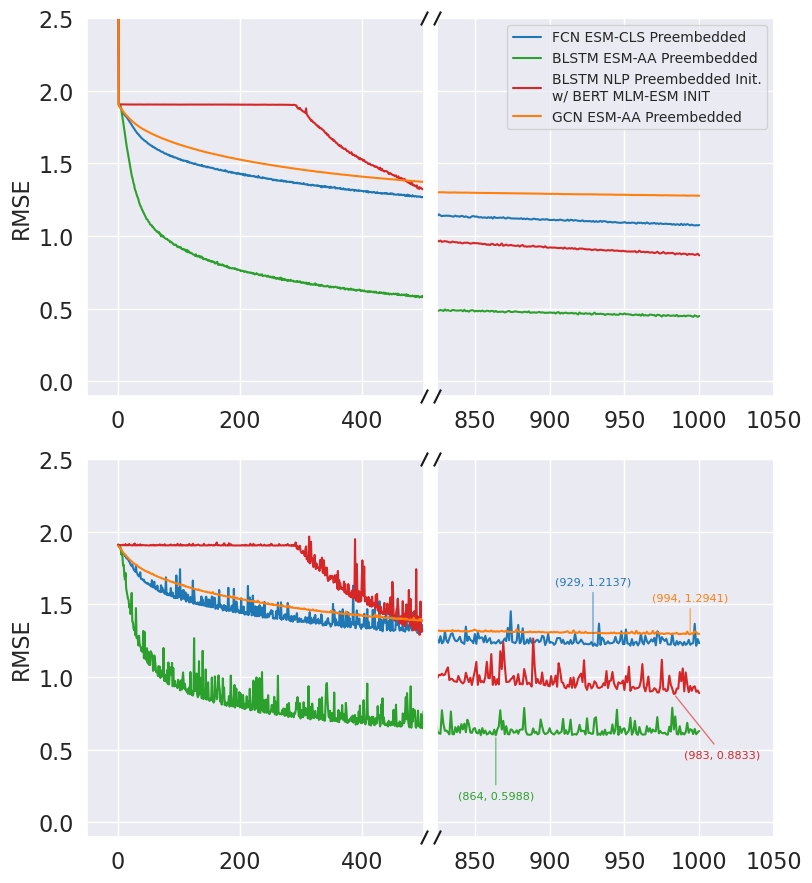

In [387]:
def plot_comparative_log_file(metrics_csv_1, metrics_csv_2, metrics_csv_3, metrics_csv_4, metrics_img):
    df1 = pd.read_csv(metrics_csv_1)
    df2 = pd.read_csv(metrics_csv_2)
    df3 = pd.read_csv(metrics_csv_3)
    df4 = pd.read_csv(metrics_csv_4)

    sns.set_theme(style="darkgrid")
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(8, 9), sharey=True)
    fig.subplots_adjust(wspace=0.05)
    fontsize = 16

    # Training Metrics
    ax1.plot(df1['Epoch'][:500], df1['Train RMSE'][:500], label='FCN ESM-CLS Preembedded', color='tab:blue', linestyle='-', linewidth=1.5)
    ax1.plot(df2['Epoch'][:500], df2['Train RMSE'][:500], label='BLSTM ESM-AA Preembedded', color='tab:green', linestyle='-', linewidth=1.5)
    ax1.plot(df3['Epoch'][:500], df3['Train RMSE'][:500], label='BLSTM NLP Preembedded Init.\nw/ BERT MLM-ESM INIT', color='tab:red', linestyle='-', linewidth=1.5)
    ax1.plot(df4['Epoch'][:500], df4['Train RMSE'][:500], label='GCN ESM-AA Preembedded', color='tab:orange', linestyle='-', linewidth=1.5)

    ax2.plot(df1['Epoch'][500:], df1['Train RMSE'][500:], label='FCN ESM-CLS Preembedded', color='tab:blue', linestyle='-', linewidth=1.5)
    ax2.plot(df2['Epoch'][500:], df2['Train RMSE'][500:], label='BLSTM ESM-AA Preembedded', color='tab:green', linestyle='-', linewidth=1.5)
    ax2.plot(df3['Epoch'][500:], df3['Train RMSE'][500:], label='BLSTM NLP Preembedded Init.\nw/ BERT MLM-ESM INIT', color='tab:red', linestyle='-', linewidth=1.5)
    ax2.plot(df4['Epoch'][500:], df4['Train RMSE'][500:], label='GCN ESM-AA Preembedded', color='tab:orange', linestyle='-', linewidth=1.5)

    # Testing Metrics
    ax3.plot(df1['Epoch'][:500], df1['Test RMSE'][:500], label='FCN ESM-CLS Preembedded', color='tab:blue', linestyle='-', linewidth=1.5)
    ax3.plot(df2['Epoch'][:500], df2['Test RMSE'][:500], label='BLSTM ESM-AA Preembedded', color='tab:green', linestyle='-', linewidth=1.5)
    ax3.plot(df3['Epoch'][:500], df3['Test RMSE'][:500], label='BLSTM NLP Preembedded Init.\nw/ BERT MLM-ESM INIT', color='tab:red', linestyle='-', linewidth=1.5)
    ax3.plot(df4['Epoch'][:500], df4['Test RMSE'][:500], label='GCN ESM-AA Preembedded', color='tab:orange', linestyle='-', linewidth=1.5)

    ax4.plot(df1['Epoch'][500:], df1['Test RMSE'][500:], label='FCN ESM-CLS Preembedded', color='tab:blue', linestyle='-', linewidth=1.5)
    ax4.plot(df2['Epoch'][500:], df2['Test RMSE'][500:], label='BLSTM ESM-AA Preembedded', color='tab:green', linestyle='-', linewidth=1.5)
    ax4.plot(df3['Epoch'][500:], df3['Test RMSE'][500:], label='BLSTM NLP Preembedded Init.\nw/ BERT MLM-ESM INIT', color='tab:red', linestyle='-', linewidth=1.5)
    ax4.plot(df4['Epoch'][500:], df4['Test RMSE'][500:], label='GCN ESM-AA Preembedded', color='tab:orange', linestyle='-', linewidth=1.5)

    # Plot Best Test Loss
    best_df1_rmse = find_best_epoch(metrics_csv_1, 'Test RMSE')
    best_df2_rmse = find_best_epoch(metrics_csv_2, 'Test RMSE')
    best_df3_rmse = find_best_epoch(metrics_csv_3, 'Test RMSE')
    best_df4_rmse = find_best_epoch(metrics_csv_4, 'Test RMSE')
    
    print("Best test RMSE at epoch x:")
    print(f"FCN ESM-CLS Preembedded: epoch {best_df1_rmse[0]}, rmse {best_df1_rmse[1]:.4f}")
    print(f"BLSTM ESM-AA Preembedded: epoch {best_df2_rmse[0]}, rmse {best_df2_rmse[1]:.4f}")
    print(f"BLSTM NLP Preembedded Init. w/ BERT MLM-ESM INIT: epoch {best_df3_rmse[0]}, rmse {best_df3_rmse[1]:.4f}")
    print(f"GCN ESM-AA Preembedded: epoch {best_df4_rmse[0]}, rmse {best_df4_rmse[1]:.4f}")

    ax4.annotate(
        f'({best_df1_rmse[0]}, {best_df1_rmse[1]:.4f})', best_df1_rmse, 
        textcoords="offset points", xytext=(0,50), ha='center', va='top', color='tab:blue', fontsize=fontsize-8,
        arrowprops=dict(arrowstyle="-", color='tab:blue', lw=1, alpha=0.6)
    )
    ax4.annotate(
        f'({best_df2_rmse[0]}, {best_df2_rmse[1]:.4f})', best_df2_rmse, 
        textcoords="offset points", xytext=(0,-40), ha='center', va='top', color='tab:green', fontsize=fontsize-8,
        arrowprops=dict(arrowstyle="-", color='tab:green', lw=1, alpha=0.6)
    )
    ax4.annotate(
        f'({best_df3_rmse[0]}, {best_df3_rmse[1]:.4f})', best_df3_rmse, 
        textcoords="offset points", xytext=(35,-40), ha='center', va='top', color='tab:red', fontsize=fontsize-8,
        arrowprops=dict(arrowstyle="-", color='tab:red', lw=1, alpha=0.6)
    )
    ax4.annotate(
        f'({best_df4_rmse[0]}, {best_df4_rmse[1]:.4f})', best_df4_rmse, 
        textcoords="offset points", xytext=(0,30), ha='center', va='top', color='tab:orange', fontsize=fontsize-8,
        arrowprops=dict(arrowstyle="-", color='tab:orange', lw=1, alpha=0.6)
    )

    # Customize axes
    for ax in [ax1, ax2, ax3, ax4]:
        ax.set_ylim(-0.1, 2.5)
        ax.tick_params(axis='both', labelsize=fontsize)

    ax1.set_xlim(-50, 500)
    ax2.set_xlim(825, 1050)
    ax3.set_xlim(-50, 500)
    ax4.set_xlim(825, 1050)

    ax1.set_ylabel('RMSE', fontsize=fontsize)
    ax3.set_ylabel('RMSE', fontsize=fontsize)

    # Add legend to the first subplot
    ax2.legend(loc='upper right', fontsize=fontsize-6)

    # Add the slanted lines for axis split
    d = .5
    kwargs = dict(marker=[(-d, -1), (d, 1)], markersize=10,
                linestyle="none", color='k', mec='k', mew=1.5, clip_on=False, zorder=5)
    ax1.plot([1, 1], [0, 1], transform=ax1.transAxes, **kwargs)
    ax2.plot([0, 0], [0, 1], transform=ax2.transAxes, **kwargs)
    ax3.plot([1, 1], [0, 1], transform=ax3.transAxes, **kwargs)
    ax4.plot([0, 0], [0, 1], transform=ax4.transAxes, **kwargs)

    plt.tight_layout(w_pad=0)
    plt.savefig(metrics_img, format='pdf')
    plt.savefig(metrics_img.replace('.pdf', '.png'), format='png')

fcn_esm_cls_preembedded = "../../results/run_results/fcn-ESM_CLS_preembedded/adam.lr1e-5.fcn-ESM_CLS_preembedded-DMS_OLD-binding-2024-11-15_17-49/fcn-ESM_CLS_preembedded-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
blstm_esm_aa_preembedded = "../../results/run_results/blstm-ESM_AA_preembedded/adam.lr1e-5.blstm-ESM_AA_preembedded-DMS_OLD-binding-2024-11-15_18-40/blstm-ESM_AA_preembedded-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
blstm_nlp_preembedded = "../../results/run_results/blstm-NLP_preembedded/adam.lr1e-5.blstm-NLP_preembedded-DMS_OLD-binding-2024-11-15_23-16/blstm-NLP_preembedded-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
gcn_esm_aa_preembedded = "../../results/run_results/gcn-ESM_AA_preembedded/adam.lr1e-5.gcn-ESM_AA_preembedded-DMS_OLD-binding-2024-11-21_17-06/gcn-ESM_AA_preembedded-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
comparison_file = "../../results/plots/model_comparisons/finetuning/adam.lr1e-5.preembedded.binding"

plot_comparative_log_file(fcn_esm_cls_preembedded, blstm_esm_aa_preembedded, blstm_nlp_preembedded, gcn_esm_aa_preembedded, f"{comparison_file}.model_comp_split.pdf")

Best test RMSE at epoch x:
FCN ESM-CLS Preembedded: epoch 929, rmse 1.2137
BLSTM ESM-AA Preembedded: epoch 864, rmse 0.5988
BLSTM NLP Preembedded Init. w/ BERT MLM-ESM INITT: epoch 983, rmse 0.8833
GCN ESM-AA Preembedded: epoch 994, rmse 1.2941


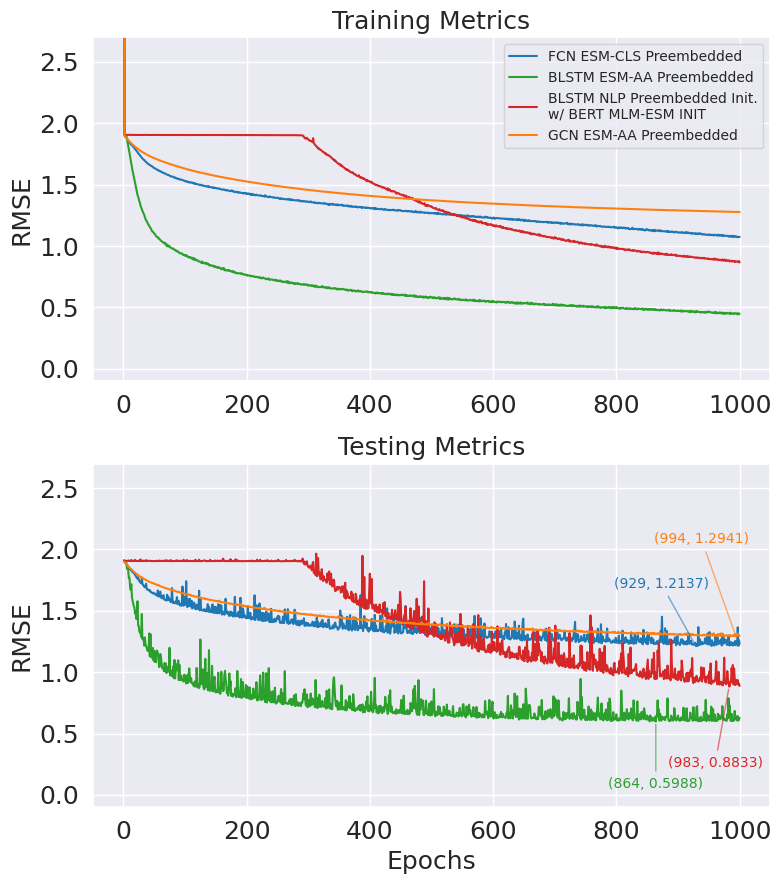

In [388]:
def plot_comparative_log_file(metrics_csv_1, metrics_csv_2, metrics_csv_3, metrics_csv_4, metrics_img):
    df1 = pd.read_csv(metrics_csv_1)
    df2 = pd.read_csv(metrics_csv_2)
    df3 = pd.read_csv(metrics_csv_3)
    df4 = pd.read_csv(metrics_csv_4)

    sns.set_theme(style="darkgrid")
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 9))  # 2 rows, 1 column
    fontsize = 18

    # Plot 1: Training Metrics (binding, expression)
    ax1.plot(df1['Epoch'], df1['Train RMSE'], label='FCN ESM-CLS Preembedded', color='tab:blue', linestyle='-', linewidth=1.5)
    ax1.plot(df2['Epoch'], df2['Train RMSE'], label='BLSTM ESM-AA Preembedded', color='tab:green', linestyle='-', linewidth=1.5)
    ax1.plot(df3['Epoch'], df3['Train RMSE'], label='BLSTM NLP Preembedded Init.\nw/ BERT MLM-ESM INIT', color='tab:red', linestyle='-', linewidth=1.5)
    ax1.plot(df4['Epoch'], df4['Train RMSE'], label='GCN ESM-AA Preembedded', color='tab:orange', linestyle='-', linewidth=1.5)

    ax1.tick_params(axis='x', labelsize=fontsize)    
    ax1.set_xlim(-50, 1050)
    ax1.set_ylabel('RMSE', fontsize=fontsize)
    ax1.tick_params(axis='y', labelsize=fontsize)
    ax1.set_ylim(-0.1, 2.7)
    ax1.legend(loc='upper right', fontsize=fontsize-8)
    ax1.set_title('Training Metrics', fontsize=fontsize)

    # Plot Best Test Loss
    best_df1_rmse = find_best_epoch(metrics_csv_1, 'Test RMSE')
    best_df2_rmse = find_best_epoch(metrics_csv_2, 'Test RMSE')
    best_df3_rmse = find_best_epoch(metrics_csv_3, 'Test RMSE')
    best_df4_rmse = find_best_epoch(metrics_csv_4, 'Test RMSE')

    print("Best test RMSE at epoch x:")
    print(f"FCN ESM-CLS Preembedded: epoch {best_df1_rmse[0]}, rmse {best_df1_rmse[1]:.4f}")
    print(f"BLSTM ESM-AA Preembedded: epoch {best_df2_rmse[0]}, rmse {best_df2_rmse[1]:.4f}")
    print(f"BLSTM NLP Preembedded Init. w/ BERT MLM-ESM INITT: epoch {best_df3_rmse[0]}, rmse {best_df3_rmse[1]:.4f}")
    print(f"GCN ESM-AA Preembedded: epoch {best_df4_rmse[0]}, rmse {best_df4_rmse[1]:.4f}")

    ax2.annotate(
        f'({best_df1_rmse[0]}, {best_df1_rmse[1]:.4f})', best_df1_rmse, 
        textcoords="offset points", xytext=(-25,50), ha='center', va='top', color='tab:blue', fontsize=fontsize-8,
        arrowprops=dict(arrowstyle="-", color='tab:blue', lw=1, alpha=0.6)
    )
    ax2.annotate(
        f'({best_df2_rmse[0]}, {best_df2_rmse[1]:.4f})', best_df2_rmse, 
        textcoords="offset points", xytext=(0,-40), ha='center', va='top', color='tab:green', fontsize=fontsize-8,
        arrowprops=dict(arrowstyle="-", color='tab:green', lw=1, alpha=0.6)
    )
    ax2.annotate(
        f'({best_df3_rmse[0]}, {best_df3_rmse[1]:.4f})', best_df3_rmse, 
        textcoords="offset points", xytext=(-10,-50), ha='center', va='top', color='tab:red', fontsize=fontsize-8,
        arrowprops=dict(arrowstyle="-", color='tab:red', lw=1, alpha=0.6)
    )
    ax2.annotate(
        f'({best_df4_rmse[0]}, {best_df4_rmse[1]:.4f})', best_df4_rmse, 
        textcoords="offset points", xytext=(-25,75), ha='center', va='top', color='tab:orange', fontsize=fontsize-8,
        arrowprops=dict(arrowstyle="-", color='tab:orange', lw=1, alpha=0.6)
    )

    # Plot 2: Testing Metrics (binding, expression)
    ax2.plot(df1['Epoch'], df1['Test RMSE'], label='FCN ESM-CLS Preembedded', color='tab:blue', linestyle='-', linewidth=1.5)
    ax2.plot(df2['Epoch'], df2['Test RMSE'], label='BLSTM ESM-AA Preembedded', color='tab:green', linestyle='-', linewidth=1.5)
    ax2.plot(df3['Epoch'], df3['Test RMSE'], label='BLSTM NLP Preembedded Init.\nw/ BERT MLM-ESM INIT', color='tab:red', linestyle='-', linewidth=1.5)
    ax2.plot(df4['Epoch'], df4['Test RMSE'], label='GCN ESM-AA Preembedded', color='tab:orange', linestyle='-', linewidth=1.5)

    ax2.set_xlabel('Epochs', fontsize=fontsize)
    ax2.tick_params(axis='x', labelsize=fontsize)
    ax2.set_xlim(-50, 1050)
    ax2.set_ylabel('RMSE', fontsize=fontsize)
    ax2.tick_params(axis='y', labelsize=fontsize)
    ax2.set_ylim(-0.1, 2.7)
    ax2.set_title('Testing Metrics', fontsize=fontsize)

    plt.tight_layout()
    plt.savefig(metrics_img, format='pdf')
    plt.savefig(metrics_img.replace('.pdf', '.png'), format='png')

fcn_esm_cls_preembedded = "../../results/run_results/fcn-ESM_CLS_preembedded/adam.lr1e-5.fcn-ESM_CLS_preembedded-DMS_OLD-binding-2024-11-15_17-49/fcn-ESM_CLS_preembedded-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
blstm_esm_aa_preembedded = "../../results/run_results/blstm-ESM_AA_preembedded/adam.lr1e-5.blstm-ESM_AA_preembedded-DMS_OLD-binding-2024-11-15_18-40/blstm-ESM_AA_preembedded-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
blstm_nlp_preembedded = "../../results/run_results/blstm-NLP_preembedded/adam.lr1e-5.blstm-NLP_preembedded-DMS_OLD-binding-2024-11-15_23-16/blstm-NLP_preembedded-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
gcn_esm_aa_preembedded = "../../results/run_results/gcn-ESM_AA_preembedded/adam.lr1e-5.gcn-ESM_AA_preembedded-DMS_OLD-binding-2024-11-21_17-06/gcn-ESM_AA_preembedded-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
comparison_file = "../../results/plots/model_comparisons/finetuning/adam.lr1e-5.preembedded.binding"

plot_comparative_log_file(fcn_esm_cls_preembedded, blstm_esm_aa_preembedded, blstm_nlp_preembedded, gcn_esm_aa_preembedded, f"{comparison_file}.model_comp.pdf")

Expression

Best test RMSE at epoch x:
FCN ESM-CLS Preembedded: epoch 991, rmse 0.6180
BLSTM ESM-AA Preembedded: epoch 952, rmse 0.3603
BLSTM NLP Preembedded Init. w/ BERT MLM-ESM INIT: epoch 1000, rmse 0.5418
GCN ESM-AA Preembedded: epoch 992, rmse 0.6819


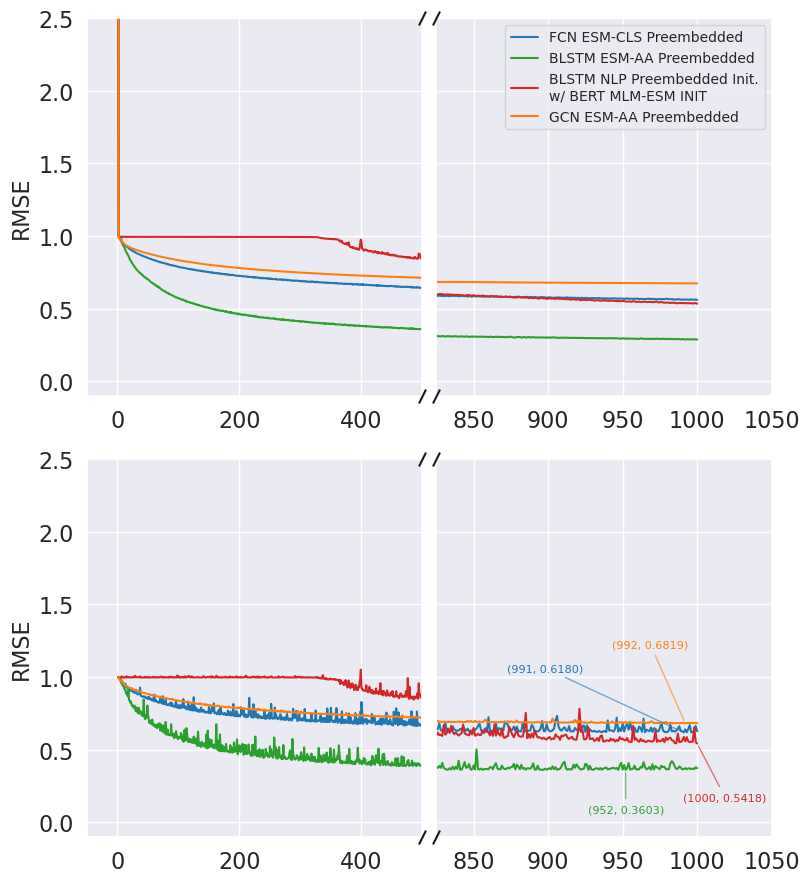

In [389]:
def plot_comparative_log_file(metrics_csv_1, metrics_csv_2, metrics_csv_3, metrics_csv_4, metrics_img):
    df1 = pd.read_csv(metrics_csv_1)
    df2 = pd.read_csv(metrics_csv_2)
    df3 = pd.read_csv(metrics_csv_3)
    df4 = pd.read_csv(metrics_csv_4)

    sns.set_theme(style="darkgrid")
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(8, 9), sharey=True)
    fig.subplots_adjust(wspace=0.05)
    fontsize = 16

    # Training Metrics
    ax1.plot(df1['Epoch'][:500], df1['Train RMSE'][:500], label='FCN ESM-CLS Preembedded', color='tab:blue', linestyle='-', linewidth=1.5)
    ax1.plot(df2['Epoch'][:500], df2['Train RMSE'][:500], label='BLSTM ESM-AA Preembedded', color='tab:green', linestyle='-', linewidth=1.5)
    ax1.plot(df3['Epoch'][:500], df3['Train RMSE'][:500], label='BLSTM NLP Preembedded Init.\nw/ BERT MLM-ESM INIT', color='tab:red', linestyle='-', linewidth=1.5)
    ax1.plot(df4['Epoch'][:500], df4['Train RMSE'][:500], label='GCN ESM-AA Preembedded', color='tab:orange', linestyle='-', linewidth=1.5)

    ax2.plot(df1['Epoch'][500:], df1['Train RMSE'][500:], label='FCN ESM-CLS Preembedded', color='tab:blue', linestyle='-', linewidth=1.5)
    ax2.plot(df2['Epoch'][500:], df2['Train RMSE'][500:], label='BLSTM ESM-AA Preembedded', color='tab:green', linestyle='-', linewidth=1.5)
    ax2.plot(df3['Epoch'][500:], df3['Train RMSE'][500:], label='BLSTM NLP Preembedded Init.\nw/ BERT MLM-ESM INIT', color='tab:red', linestyle='-', linewidth=1.5)
    ax2.plot(df4['Epoch'][500:], df4['Train RMSE'][500:], label='GCN ESM-AA Preembedded', color='tab:orange', linestyle='-', linewidth=1.5)

    # Testing Metrics
    ax3.plot(df1['Epoch'][:500], df1['Test RMSE'][:500], label='FCN ESM-CLS Preembedded', color='tab:blue', linestyle='-', linewidth=1.5)
    ax3.plot(df2['Epoch'][:500], df2['Test RMSE'][:500], label='BLSTM ESM-AA Preembedded', color='tab:green', linestyle='-', linewidth=1.5)
    ax3.plot(df3['Epoch'][:500], df3['Test RMSE'][:500], label='BLSTM NLP Preembedded Init.\nw/ BERT MLM-ESM INIT', color='tab:red', linestyle='-', linewidth=1.5)
    ax3.plot(df4['Epoch'][:500], df4['Test RMSE'][:500], label='GCN ESM-AA Preembedded', color='tab:orange', linestyle='-', linewidth=1.5)

    ax4.plot(df1['Epoch'][500:], df1['Test RMSE'][500:], label='FCN ESM-CLS Preembedded', color='tab:blue', linestyle='-', linewidth=1.5)
    ax4.plot(df2['Epoch'][500:], df2['Test RMSE'][500:], label='BLSTM ESM-AA Preembedded', color='tab:green', linestyle='-', linewidth=1.5)
    ax4.plot(df3['Epoch'][500:], df3['Test RMSE'][500:], label='BLSTM NLP Preembedded Init.\nw/ BERT MLM-ESM INIT', color='tab:red', linestyle='-', linewidth=1.5)
    ax4.plot(df4['Epoch'][500:], df4['Test RMSE'][500:], label='GCN ESM-AA Preembedded', color='tab:orange', linestyle='-', linewidth=1.5)

    # Plot Best Test Loss
    best_df1_rmse = find_best_epoch(metrics_csv_1, 'Test RMSE')
    best_df2_rmse = find_best_epoch(metrics_csv_2, 'Test RMSE')
    best_df3_rmse = find_best_epoch(metrics_csv_3, 'Test RMSE')
    best_df4_rmse = find_best_epoch(metrics_csv_4, 'Test RMSE')
    
    print("Best test RMSE at epoch x:")
    print(f"FCN ESM-CLS Preembedded: epoch {best_df1_rmse[0]}, rmse {best_df1_rmse[1]:.4f}")
    print(f"BLSTM ESM-AA Preembedded: epoch {best_df2_rmse[0]}, rmse {best_df2_rmse[1]:.4f}")
    print(f"BLSTM NLP Preembedded Init. w/ BERT MLM-ESM INIT: epoch {best_df3_rmse[0]}, rmse {best_df3_rmse[1]:.4f}")
    print(f"GCN ESM-AA Preembedded: epoch {best_df4_rmse[0]}, rmse {best_df4_rmse[1]:.4f}")

    ax4.annotate(
        f'({best_df1_rmse[0]}, {best_df1_rmse[1]:.4f})', best_df1_rmse, 
        textcoords="offset points", xytext=(-100,50), ha='center', va='top', color='tab:blue', fontsize=fontsize-8,
        arrowprops=dict(arrowstyle="-", color='tab:blue', lw=1, alpha=0.6)
    )
    ax4.annotate(
        f'({best_df2_rmse[0]}, {best_df2_rmse[1]:.4f})', best_df2_rmse, 
        textcoords="offset points", xytext=(0,-25), ha='center', va='top', color='tab:green', fontsize=fontsize-8,
        arrowprops=dict(arrowstyle="-", color='tab:green', lw=1, alpha=0.6)
    )
    ax4.annotate(
        f'({best_df3_rmse[0]}, {best_df3_rmse[1]:.4f})', best_df3_rmse, 
        textcoords="offset points", xytext=(20,-35), ha='center', va='top', color='tab:red', fontsize=fontsize-8,
        arrowprops=dict(arrowstyle="-", color='tab:red', lw=1, alpha=0.6)
    )
    ax4.annotate(
        f'({best_df4_rmse[0]}, {best_df4_rmse[1]:.4f})', best_df4_rmse, 
        textcoords="offset points", xytext=(-25,60), ha='center', va='top', color='tab:orange', fontsize=fontsize-8,
        arrowprops=dict(arrowstyle="-", color='tab:orange', lw=1, alpha=0.6)
    )

    # Customize axes
    for ax in [ax1, ax2, ax3, ax4]:
        ax.set_ylim(-0.1, 2.5)
        ax.tick_params(axis='both', labelsize=fontsize)

    ax1.set_xlim(-50, 500)
    ax2.set_xlim(825, 1050)
    ax3.set_xlim(-50, 500)
    ax4.set_xlim(825, 1050)

    ax1.set_ylabel('RMSE', fontsize=fontsize)
    ax3.set_ylabel('RMSE', fontsize=fontsize)

    # Add legend to the first subplot
    ax2.legend(loc='upper right', fontsize=fontsize-6)

    # Add the slanted lines for axis split
    d = .5
    kwargs = dict(marker=[(-d, -1), (d, 1)], markersize=10,
                linestyle="none", color='k', mec='k', mew=1.5, clip_on=False, zorder=5)
    ax1.plot([1, 1], [0, 1], transform=ax1.transAxes, **kwargs)
    ax2.plot([0, 0], [0, 1], transform=ax2.transAxes, **kwargs)
    ax3.plot([1, 1], [0, 1], transform=ax3.transAxes, **kwargs)
    ax4.plot([0, 0], [0, 1], transform=ax4.transAxes, **kwargs)

    plt.tight_layout(w_pad=0)
    plt.savefig(metrics_img, format='pdf')
    plt.savefig(metrics_img.replace('.pdf', '.png'), format='png')

fcn_esm_cls_preembedded = "../../results/run_results/fcn-ESM_CLS_preembedded/adam.lr1e-5.fcn-ESM_CLS_preembedded-DMS_OLD-expression-2024-11-15_17-58/fcn-ESM_CLS_preembedded-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
blstm_esm_aa_preembedded = "../../results/run_results/blstm-ESM_AA_preembedded/adam.lr1e-5.blstm-ESM_AA_preembedded-DMS_OLD-expression-2024-11-15_18-41/blstm-ESM_AA_preembedded-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
blstm_nlp_preembedded = "../../results/run_results/blstm-NLP_preembedded/adam.lr1e-5.blstm-NLP_preembedded-DMS_OLD-expression-2024-11-15_23-17/blstm-NLP_preembedded-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
gcn_esm_aa_preembedded = "../../results/run_results/gcn-ESM_AA_preembedded/adam.lr1e-5.gcn-ESM_AA_preembedded-DMS_OLD-expression-2024-11-16_20-10/gcn-ESM_AA_preembedded-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
comparison_file = "../../results/plots/model_comparisons/finetuning/adam.lr1e-5.preembedded.expression"

plot_comparative_log_file(fcn_esm_cls_preembedded, blstm_esm_aa_preembedded, blstm_nlp_preembedded, gcn_esm_aa_preembedded, f"{comparison_file}.model_comp_split.pdf")

Best test RMSE at epoch x:
FCN ESM-CLS Preembedded: epoch 991, rmse 0.6180
BLSTM ESM-AA Preembedded: epoch 952, rmse 0.3603
BLSTM NLP Preembedded w/ Finetuned BERT_MLM_ESM_INIT: epoch 1000, rmse 0.5418
GCN ESM-AA Preembedded: epoch 992, rmse 0.6819


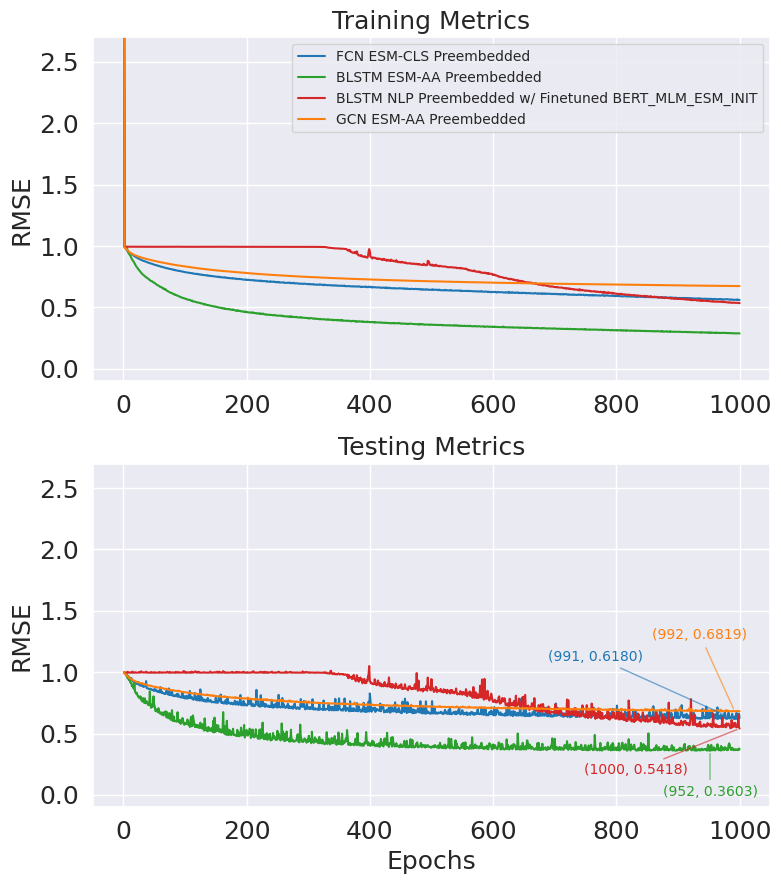

In [390]:
def plot_comparative_log_file(metrics_csv_1, metrics_csv_2, metrics_csv_3, metrics_csv_4, metrics_img):
    df1 = pd.read_csv(metrics_csv_1)
    df2 = pd.read_csv(metrics_csv_2)
    df3 = pd.read_csv(metrics_csv_3)
    df4 = pd.read_csv(metrics_csv_4)

    sns.set_theme(style="darkgrid")
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 9))  # 2 rows, 1 column
    fontsize = 18

    # Plot 1: Training Metrics (binding, expression)
    ax1.plot(df1['Epoch'], df1['Train RMSE'], label='FCN ESM-CLS Preembedded', color='tab:blue', linestyle='-', linewidth=1.5)
    ax1.plot(df2['Epoch'], df2['Train RMSE'], label='BLSTM ESM-AA Preembedded', color='tab:green', linestyle='-', linewidth=1.5)
    ax1.plot(df3['Epoch'], df3['Train RMSE'], label='BLSTM NLP Preembedded w/ Finetuned BERT_MLM_ESM_INIT', color='tab:red', linestyle='-', linewidth=1.5)
    ax1.plot(df4['Epoch'], df4['Train RMSE'], label='GCN ESM-AA Preembedded', color='tab:orange', linestyle='-', linewidth=1.5)

    ax1.tick_params(axis='x', labelsize=fontsize)    
    ax1.set_xlim(-50, 1050)
    ax1.set_ylabel('RMSE', fontsize=fontsize)
    ax1.tick_params(axis='y', labelsize=fontsize)
    ax1.set_ylim(-0.1, 2.7)
    ax1.legend(loc='upper right', fontsize=fontsize-8)
    ax1.set_title('Training Metrics', fontsize=fontsize)

    # Plot Best Test Loss
    best_df1_rmse = find_best_epoch(metrics_csv_1, 'Test RMSE')
    best_df2_rmse = find_best_epoch(metrics_csv_2, 'Test RMSE')
    best_df3_rmse = find_best_epoch(metrics_csv_3, 'Test RMSE')
    best_df4_rmse = find_best_epoch(metrics_csv_4, 'Test RMSE')

    print("Best test RMSE at epoch x:")
    print(f"FCN ESM-CLS Preembedded: epoch {best_df1_rmse[0]}, rmse {best_df1_rmse[1]:.4f}")
    print(f"BLSTM ESM-AA Preembedded: epoch {best_df2_rmse[0]}, rmse {best_df2_rmse[1]:.4f}")
    print(f"BLSTM NLP Preembedded w/ Finetuned BERT_MLM_ESM_INIT: epoch {best_df3_rmse[0]}, rmse {best_df3_rmse[1]:.4f}")
    print(f"GCN ESM-AA Preembedded: epoch {best_df4_rmse[0]}, rmse {best_df4_rmse[1]:.4f}")

    ax2.annotate(
        f'({best_df1_rmse[0]}, {best_df1_rmse[1]:.4f})', best_df1_rmse, 
        textcoords="offset points", xytext=(-100,50), ha='center', va='top', color='tab:blue', fontsize=fontsize-8,
        arrowprops=dict(arrowstyle="-", color='tab:blue', lw=1, alpha=0.6)
    )
    ax2.annotate(
        f'({best_df2_rmse[0]}, {best_df2_rmse[1]:.4f})', best_df2_rmse, 
        textcoords="offset points", xytext=(0,-25), ha='center', va='top', color='tab:green', fontsize=fontsize-8,
        arrowprops=dict(arrowstyle="-", color='tab:green', lw=1, alpha=0.6)
    )
    ax2.annotate(
        f'({best_df3_rmse[0]}, {best_df3_rmse[1]:.4f})', best_df3_rmse, 
        textcoords="offset points", xytext=(-75,-25), ha='center', va='top', color='tab:red', fontsize=fontsize-8,
        arrowprops=dict(arrowstyle="-", color='tab:red', lw=1, alpha=0.6)
    )
    ax2.annotate(
        f'({best_df4_rmse[0]}, {best_df4_rmse[1]:.4f})', best_df4_rmse, 
        textcoords="offset points", xytext=(-25,60), ha='center', va='top', color='tab:orange', fontsize=fontsize-8,
        arrowprops=dict(arrowstyle="-", color='tab:orange', lw=1, alpha=0.6)
    )

    # Plot 2: Testing Metrics (binding, expression)
    ax2.plot(df1['Epoch'], df1['Test RMSE'], label='FCN ESM-CLS Preembedded', color='tab:blue', linestyle='-', linewidth=1.5)
    ax2.plot(df2['Epoch'], df2['Test RMSE'], label='BLSTM ESM-AA Preembedded', color='tab:green', linestyle='-', linewidth=1.5)
    ax2.plot(df3['Epoch'], df3['Test RMSE'], label='BLSTM NLP Preembedded w/ Finetuned BERT_MLM_ESM_INIT', color='tab:red', linestyle='-', linewidth=1.5)
    ax2.plot(df4['Epoch'], df4['Test RMSE'], label='GCN ESM-AA Preembedded', color='tab:orange', linestyle='-', linewidth=1.5)

    ax2.set_xlabel('Epochs', fontsize=fontsize)
    ax2.tick_params(axis='x', labelsize=fontsize)
    ax2.set_xlim(-50, 1050)
    ax2.set_ylabel('RMSE', fontsize=fontsize)
    ax2.tick_params(axis='y', labelsize=fontsize)
    ax2.set_ylim(-0.1, 2.7)
    ax2.set_title('Testing Metrics', fontsize=fontsize)

    plt.tight_layout()
    plt.savefig(metrics_img, format='pdf')
    plt.savefig(metrics_img.replace('.pdf', '.png'), format='png')

fcn_esm_cls_preembedded = "../../results/run_results/fcn-ESM_CLS_preembedded/adam.lr1e-5.fcn-ESM_CLS_preembedded-DMS_OLD-expression-2024-11-15_17-58/fcn-ESM_CLS_preembedded-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
blstm_esm_aa_preembedded = "../../results/run_results/blstm-ESM_AA_preembedded/adam.lr1e-5.blstm-ESM_AA_preembedded-DMS_OLD-expression-2024-11-15_18-41/blstm-ESM_AA_preembedded-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
blstm_nlp_preembedded = "../../results/run_results/blstm-NLP_preembedded/adam.lr1e-5.blstm-NLP_preembedded-DMS_OLD-expression-2024-11-15_23-17/blstm-NLP_preembedded-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
gcn_esm_aa_preembedded = "../../results/run_results/gcn-ESM_AA_preembedded/adam.lr1e-5.gcn-ESM_AA_preembedded-DMS_OLD-expression-2024-11-16_20-10/gcn-ESM_AA_preembedded-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
comparison_file = "../../results/plots/model_comparisons/finetuning/adam.lr1e-5.preembedded.expression"

plot_comparative_log_file(fcn_esm_cls_preembedded, blstm_esm_aa_preembedded, blstm_nlp_preembedded, gcn_esm_aa_preembedded, f"{comparison_file}.model_comp.pdf")